# Poređenje algoritama mašinskog učenja za predviđanje cena nekretnina

## Istraživačko pitanje

> **Koji algoritam daje najbolje rezultate za predviđanje cena nekretnina na ovom tabelarnom skupu podataka?**

Cilj ovog rada nije da unapred favorizuje bilo koji model, već da se
**eksperimentalno, na fer i reproduktivan način** utvrdi koji od nekoliko
standardnih algoritama mašinskog učenja najbolje predviđa tržišnu cenu
nekretnine na osnovu njenih karakteristika (površina, broj soba, sprat,
lokacija, dodatne pogodnosti...).

## Modeli koji se porede

| Model | Tip | Zašto je uključen |
|---|---|---|
| Linear Regression | Linearni | Najjednostavniji mogući baseline - donja granica očekivanog učinka |
| Decision Tree | Stablo odlučivanja | Jednostavan nelinearni model, osnova za ansamble |
| Random Forest | Ansambl stabala (bagging) | Standardni snažan baseline za tabelarne podatke |
| XGBoost | Gradient boosting | Industrijski standard za tabelarne podatke u takmičenjima i praksi |
| CatBoost | Gradient boosting | Nativna podrška kategorijskih atributa, manja potreba za preprocessing-om |
| LightGBM | Gradient boosting (histogram-based) | Veoma brz trening, mala potrošnja memorije |
| MLP (neuronska mreža) | Duboko učenje | Fleksibilan univerzalni aproksimator, tema veštačke inteligencije |

## Protokol poređenja (fer i reproduktivno)

Da bi poređenje bilo validno, **svi modeli koriste**:
- isti skup ulaznih karakteristika i isti preprocessing pipeline (StandardScaler + OneHotEncoder),
- istu podelu na train/test (`random_state` fiksiran),
- istu 5-strukog unakrsnu validaciju (K-Fold, isti splitovi za sve modele) za poređenje i statističke testove,
- istu ciljnu promenljivu - `log1p(cena)` pri treniranju, sa vraćanjem u evre (`expm1`) pri evaluaciji,
- iste metrike: MAE, RMSE, MAPE, R² (na EUR skali, na test skupu koji nijedan model nije video tokom treniranja/tuning-a).

## Struktura notebook-a

1. Uvod
2. Učitavanje podataka
3. Istraživačka analiza podataka (EDA) - na sirovim podacima
4. Čišćenje podataka
5. Feature Engineering
6. Log transformacija ciljne promenljive
7. Preprocessing Pipeline
8. Train/Test Split
9. Cross Validation - protokol
10. Linear Regression
11. Decision Tree
12. Random Forest (+ tuning)
13. XGBoost (+ tuning)
14. CatBoost (+ tuning)
15. LightGBM (+ tuning)
16. MLP neuronska mreža (+ arhitektura)
17. Pregled hiperparametarskog podešavanja
18. Evaluacija i poređenje modela
19. Vizuelno poređenje modela
20. Statističko poređenje modela
21. Residual analiza
22. Feature Importance
23. SHAP analiza
24. Diskusija rezultata
25. Završni zaključak

## 2. Učitavanje podataka

In [1]:
import os
import json
import time
import pickle
import warnings
from itertools import combinations

# TensorFlow ispisuje dosta INFO/WARNING poruka o oneDNN optimizacijama i
# dostupnim CPU instrukcijama pri uvozu - bezopasne su, ali zatrpavaju izlaz,
# pa ih utišavamo PRE uvoza tensorflow-a.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

CSV_PATH = "../data/nekretnine_listings.csv"
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

BELGRADE_CENTER_LAT = 44.8125
BELGRADE_CENTER_LON = 20.4612

print("Biblioteke uspešno učitane.")
print("TensorFlow verzija:", tf.__version__)

Biblioteke uspešno učitane.
TensorFlow verzija: 2.21.0


In [2]:
df_raw = pd.read_csv(CSV_PATH)
print(f"Sirovi skup podataka: {df_raw.shape[0]} redova, {df_raw.shape[1]} kolona")
df_raw.head()

Sirovi skup podataka: 1915 redova, 30 kolona


,listing_id,url,title,contract,is_new,price_eur,price_raw,price_visible,typology,category,...,heating,municipality,neighborhood,city,address,latitude,longitude,agency,description,source_file
0,41749,https://www.nekretnine.rs/oglasi/41749/,"Četvorosobni stan Ulica Danijelova 10, Dušanov...",sale,False,615000.0,€ 615.000,True,Četvorosobni stan,Stambene nekretnine,...,Autonomo,Voždovac,Dušanovac,Beograd,Ulica Danijelova,44.784199,20.477200,UNITED CITY GROUP,* ALTERRA VERSA - SMART HOME! * 153 m2 + 115 m...,beograd_page_001.html
1,41747,https://www.nekretnine.rs/oglasi/41747/,"Četvorosobni stan Ulica Danijelova 10, Dušanov...",sale,False,257000.0,€ 257.000,True,Četvorosobni stan,Stambene nekretnine,...,Autonomo,Voždovac,Dušanovac,Beograd,Ulica Danijelova,44.784199,20.477200,UNITED CITY GROUP,U „Alterra Versa“ objektu ne kupujete samo kva...,beograd_page_001.html
2,77431,https://www.nekretnine.rs/oglasi/77431/,"Četvorosobni stan Bulevar Mihajla Pupina, Akad...",sale,False,750000.0,€ 750.000,True,Četvorosobni stan,Stambene nekretnine,...,Centralizzato,Novi Beograd,Akademija - Arena,Beograd,Bulevar Mihajla Pupina,44.821098,20.420099,BEOSTATUS,"Na Novom Beogradu, Bul Mihajla Pupina u čuveno...",beograd_page_001.html
3,1015817,https://www.nekretnine.rs/oglasi/1015817/,"Dvosobni stan Ulica Omladinskih brigada, Belvi...",sale,False,261250.0,€ 261.250,True,Dvosobni stan,Stambene nekretnine,...,Centralizzato,Novi Beograd,Belvil,Beograd,Ulica Omladinskih brigada,44.812698,20.402800,DANOS AND ASSOCIATES,"Soul 64 Novo, 2.0 na veoma traženoj lokaciji b...",beograd_page_001.html
4,1210527,https://www.nekretnine.rs/oglasi/1210527/,"Zgrada Ulica Ustanicka 92, Šumice, Beograd",sale,False,229482.0,€ 229.482,True,Zgrada,Zgrade - Građevine,...,Assente,Voždovac,Šumice,Beograd,Ulica Ustanicka,44.784401,20.484400,arcoSITE d.o.o.,"U srcu Voždovca, na atraktivnoj lokaciji, nudi...",beograd_page_001.html


## 3. Istraživačka analiza podataka (EDA)

Analiza u ovom odeljku se radi na **sirovim, još neočišćenim** podacima -
cilj je razumeti podatke pre bilo kakve intervencije (čišćenja), i na
osnovu ove analize doneti informisane odluke o čišćenju u odeljku 4
(npr. koje granice koristiti za filtriranje outliera).

### 3.1 Dimenzije, tipovi podataka i osnovni pregled

In [3]:
print(f"Dimenzije: {df_raw.shape[0]} redova x {df_raw.shape[1]} kolona")
print()
dtype_table = pd.DataFrame({
    "Tip podatka": df_raw.dtypes.astype(str),
    "Broj jedinstvenih vrednosti": df_raw.nunique(),
})
dtype_table

Dimenzije: 1915 redova x 30 kolona



,Tip podatka,Broj jedinstvenih vrednosti
listing_id,int64,1915
url,str,1915
title,str,1559
contract,str,1
is_new,bool,2
price_eur,float64,701
price_raw,str,702
price_visible,bool,2
typology,str,16
category,str,3


### 3.2 Nedostajuće vrednosti

In [4]:
missing_table = pd.DataFrame({
    "Broj NaN": df_raw.isna().sum(),
    "Procenat NaN (%)": (df_raw.isna().sum() / len(df_raw) * 100).round(2),
})
missing_table = missing_table[missing_table["Broj NaN"] > 0].sort_values("Broj NaN", ascending=False)
missing_table

,Broj NaN,Procenat NaN (%)
description,1904,99.43
furnished,1731,90.39
balcony,1606,83.86
basement,1473,76.92
elevator,730,38.12
terrace,565,29.50
bedrooms,473,24.70
bathrooms,457,23.86
floor,309,16.14
address,197,10.29


### 3.3 Duplikati

In [5]:
n_duplicates = df_raw.duplicated(subset=["listing_id"]).sum()
print(f"Broj potpunih duplikata po listing_id: {n_duplicates}")
n_duplicates_full = df_raw.duplicated().sum()
print(f"Broj potpuno identičnih redova (sve kolone): {n_duplicates_full}")

Broj potpunih duplikata po listing_id: 0
Broj potpuno identičnih redova (sve kolone): 0


### 3.4 Opisna statistika numeričkih atributa

In [6]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
listing_id,1915.0,796856.947781,501324.303823,53.000000,95670.000000,1.032245e+06,1.191882e+06,1.342373e+06
price_eur,1885.0,349448.728912,294190.478720,113.000000,169800.000000,2.680000e+05,4.000000e+05,3.450000e+06
area_sqm,1912.0,107.148492,89.977402,1.000000,57.000000,8.050000e+01,1.210000e+02,9.730000e+02
bedrooms,1442.0,2.938280,1.469917,0.000000,2.000000,3.000000e+00,4.000000e+00,1.200000e+01
latitude,1872.0,44.784921,0.060870,44.349998,44.780015,4.479806e+01,4.481192e+01,4.506794e+01
longitude,1872.0,20.454095,0.070380,20.136370,20.417999,2.046400e+01,2.048580e+01,2.075810e+01


### 3.5 Distribucija ciljne promenljive (cena) i log(cena)

Cena je izrazito desno zakošena - mali broj veoma skupih nekretnina
"izdužuje" rep raspodele. Log-transformacija (`log1p`) čini raspodelu
znatno simetričnijom i bližom normalnoj, što će biti bitno pri treniranju
modela (odeljak 6).

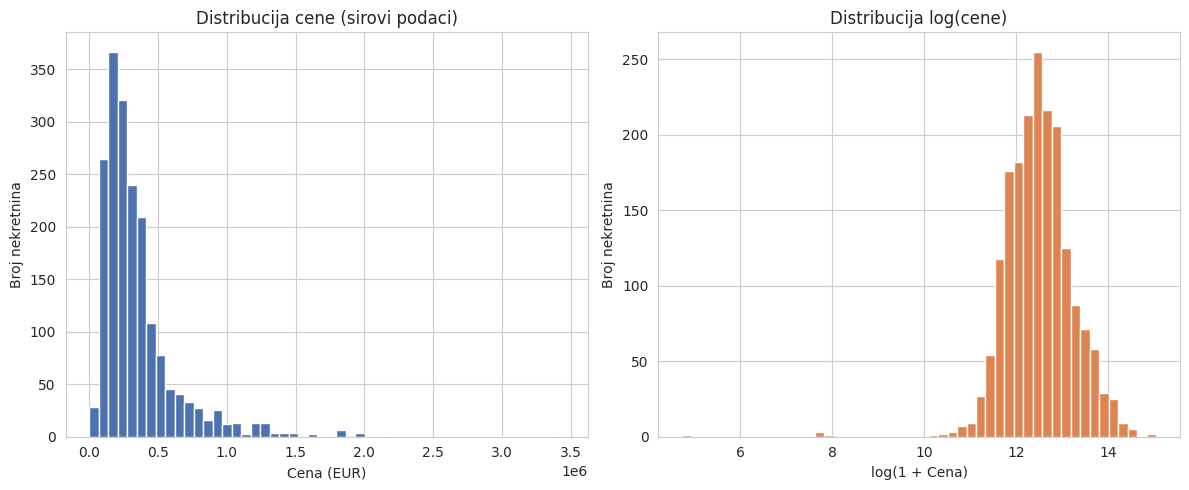

count    1.885000e+03
mean     3.494487e+05
std      2.941905e+05
min      1.130000e+02
25%      1.698000e+05
50%      2.680000e+05
75%      4.000000e+05
max      3.450000e+06
Name: price_eur, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_raw["price_eur"].dropna(), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Cena (EUR)")
axes[0].set_ylabel("Broj nekretnina")
axes[0].set_title("Distribucija cene (sirovi podaci)")

axes[1].hist(np.log1p(df_raw["price_eur"].dropna()), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("log(1 + Cena)")
axes[1].set_ylabel("Broj nekretnina")
axes[1].set_title("Distribucija log(cene)")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_price_distribution.png"), dpi=150)
plt.show()

print(df_raw["price_eur"].describe())

### 3.6 Korelaciona matrica numeričkih atributa

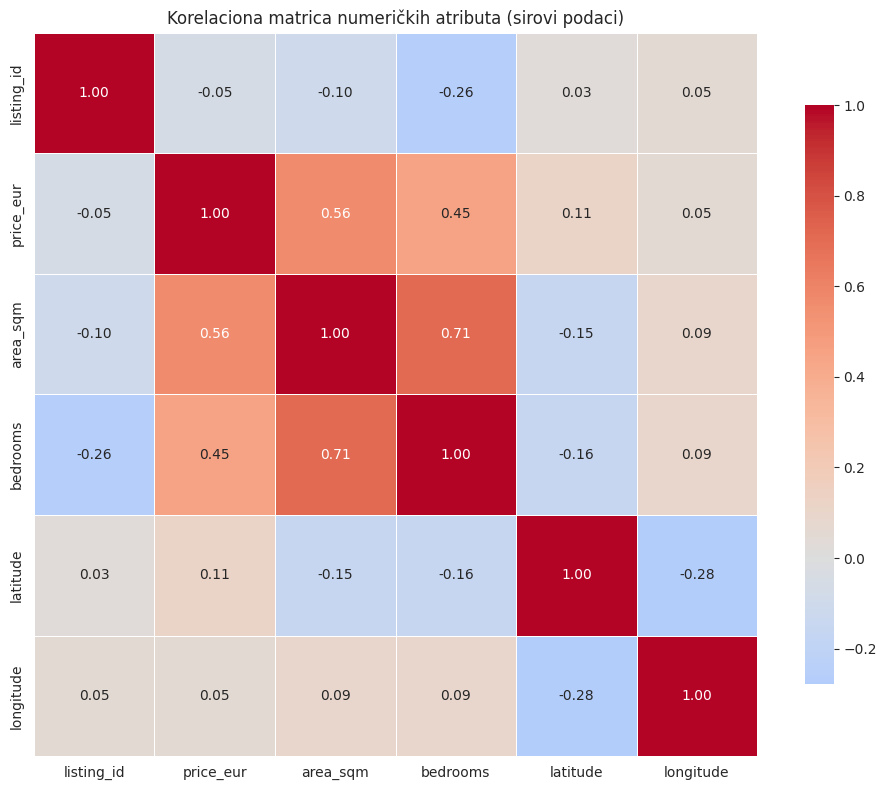

In [8]:
numeric_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix_raw = df_raw[numeric_cols_raw].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_raw, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Korelaciona matrica numeričkih atributa (sirovi podaci)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_correlation_matrix.png"), dpi=150)
plt.show()

In [9]:
corr_with_price = corr_matrix_raw["price_eur"].drop("price_eur").sort_values(ascending=False)
print("Korelacija numeričkih atributa sa cenom (price_eur):")
corr_with_price

Korelacija numeričkih atributa sa cenom (price_eur):


area_sqm      0.561551
bedrooms      0.450925
latitude      0.113534
longitude     0.051013
listing_id   -0.053880
Name: price_eur, dtype: float64

### 3.7 Histogrami svih numeričkih atributa

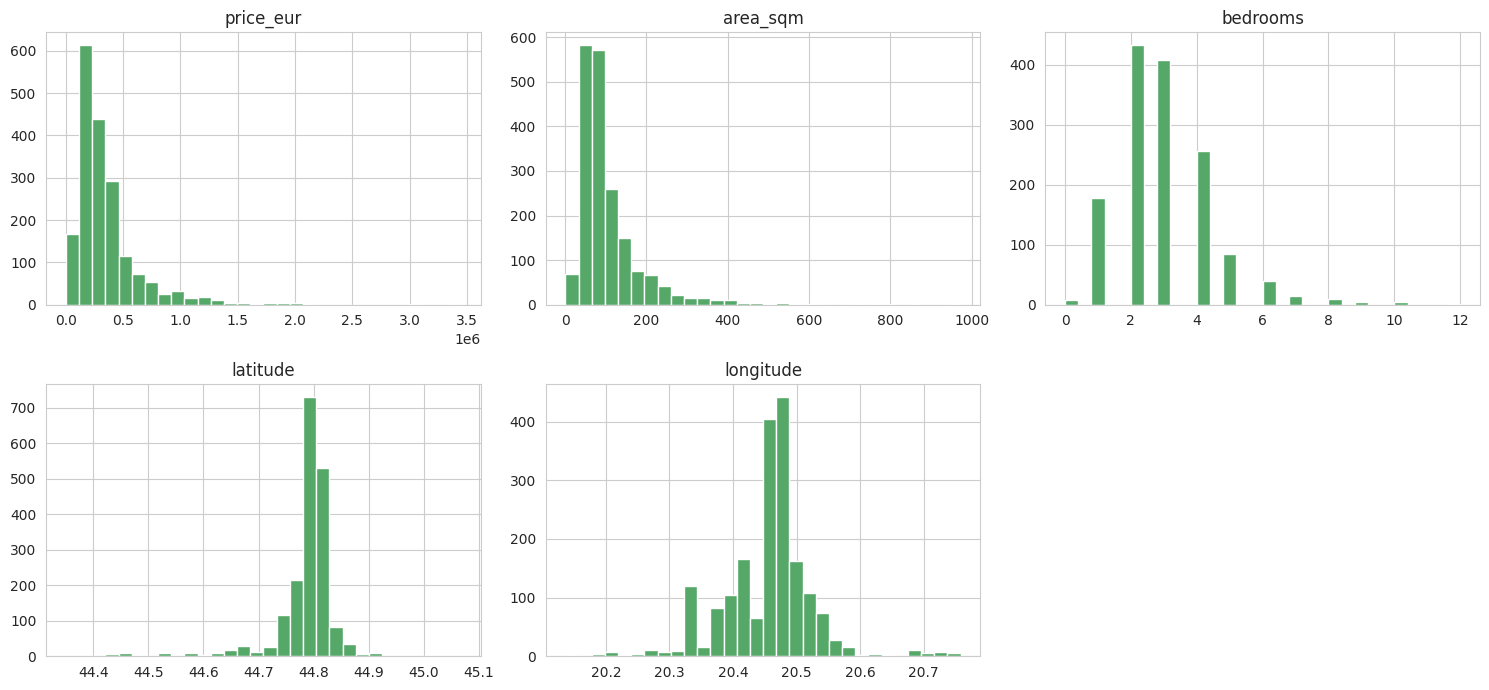

In [10]:
num_cols_for_hist = [c for c in numeric_cols_raw if c not in ("listing_id",)]
n_cols = 3
n_rows = int(np.ceil(len(num_cols_for_hist) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols_for_hist):
    axes[i].hist(df_raw[col].dropna(), bins=30, color="#55A868", edgecolor="white")
    axes[i].set_title(col)
for j in range(len(num_cols_for_hist), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_all_histograms.png"), dpi=150)
plt.show()

### 3.8 Boxplot analiza (otkrivanje outliera)

Boxplotovi ispod prikazuju cenu i površinu u sirovom obliku. Vidljiv je
mali broj ekstremnih vrednosti - ovo direktno informiše granice
filtriranja koje se koriste u odeljku 4 (čišćenje podataka).

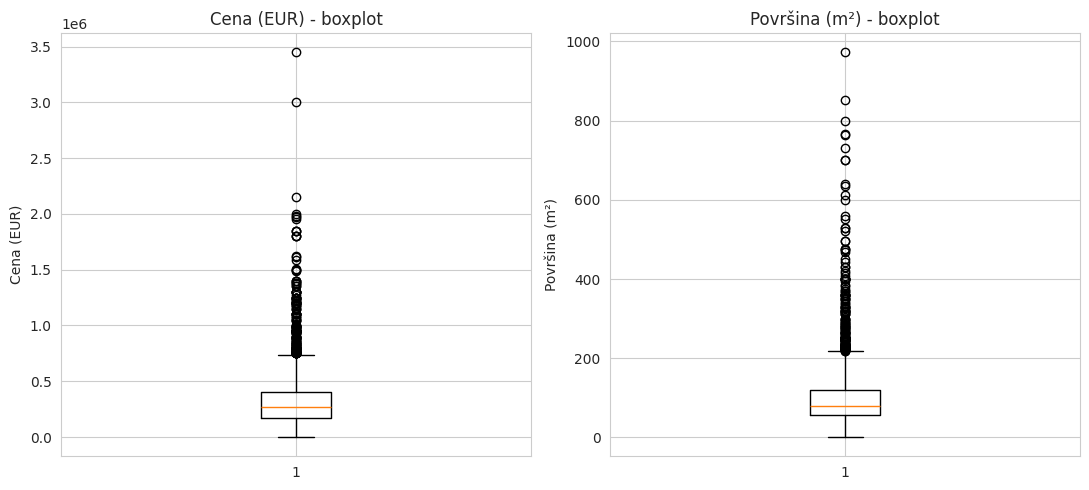

Cena - IQR granice (Q1-1.5*IQR, Q3+1.5*IQR): [-175,500, 745,300] EUR
Broj vrednosti iznad gornje IQR granice: 162


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].boxplot(df_raw["price_eur"].dropna(), vert=True)
axes[0].set_title("Cena (EUR) - boxplot")
axes[0].set_ylabel("Cena (EUR)")

axes[1].boxplot(df_raw["area_sqm"].dropna(), vert=True)
axes[1].set_title("Površina (m²) - boxplot")
axes[1].set_ylabel("Površina (m²)")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_boxplots_outliers.png"), dpi=150)
plt.show()

q1, q3 = df_raw["price_eur"].quantile([0.25, 0.75])
iqr = q3 - q1
print(f"Cena - IQR granice (Q1-1.5*IQR, Q3+1.5*IQR): "
      f"[{q1 - 1.5*iqr:,.0f}, {q3 + 1.5*iqr:,.0f}] EUR")
print(f"Broj vrednosti iznad gornje IQR granice: "
      f"{(df_raw['price_eur'] > q3 + 1.5*iqr).sum()}")

### 3.9 Cena u odnosu na najvažnije numeričke karakteristike (scatter)

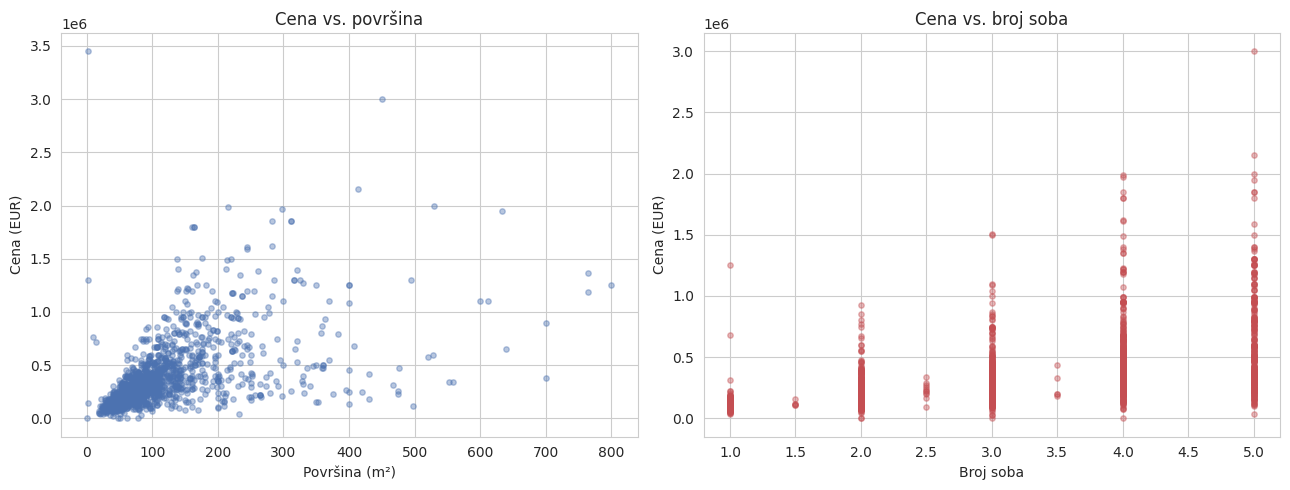

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_raw["area_sqm"], df_raw["price_eur"], alpha=0.4, s=15, color="#4C72B0")
axes[0].set_xlabel("Površina (m²)")
axes[0].set_ylabel("Cena (EUR)")
axes[0].set_title("Cena vs. površina")

axes[1].scatter(df_raw["rooms"].apply(lambda v: pd.to_numeric(str(v).replace("+", ""), errors="coerce")),
                df_raw["price_eur"], alpha=0.4, s=15, color="#C44E52")
axes[1].set_xlabel("Broj soba")
axes[1].set_ylabel("Cena (EUR)")
axes[1].set_title("Cena vs. broj soba")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_scatter_price_vs_features.png"), dpi=150)
plt.show()

### 3.10 Analiza kategorijskih atributa

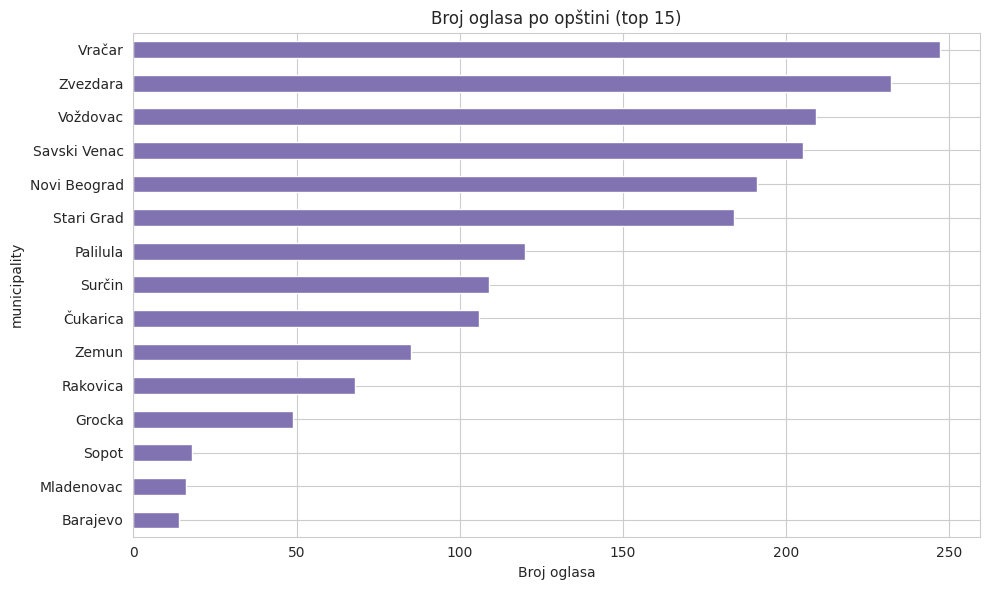

Broj jedinstvenih opština (municipality): 17
Broj jedinstvenih naselja (neighborhood): 127
Broj jedinstvenih tipova grejanja (heating): 3


In [13]:
top_municipalities = df_raw["municipality"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_municipalities.sort_values().plot(kind="barh", color="#8172B2")
plt.xlabel("Broj oglasa")
plt.title("Broj oglasa po opštini (top 15)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_municipality_counts.png"), dpi=150)
plt.show()

print(f"Broj jedinstvenih opština (municipality): {df_raw['municipality'].nunique()}")
print(f"Broj jedinstvenih naselja (neighborhood): {df_raw['neighborhood'].nunique()}")
print(f"Broj jedinstvenih tipova grejanja (heating): {df_raw['heating'].nunique()}")

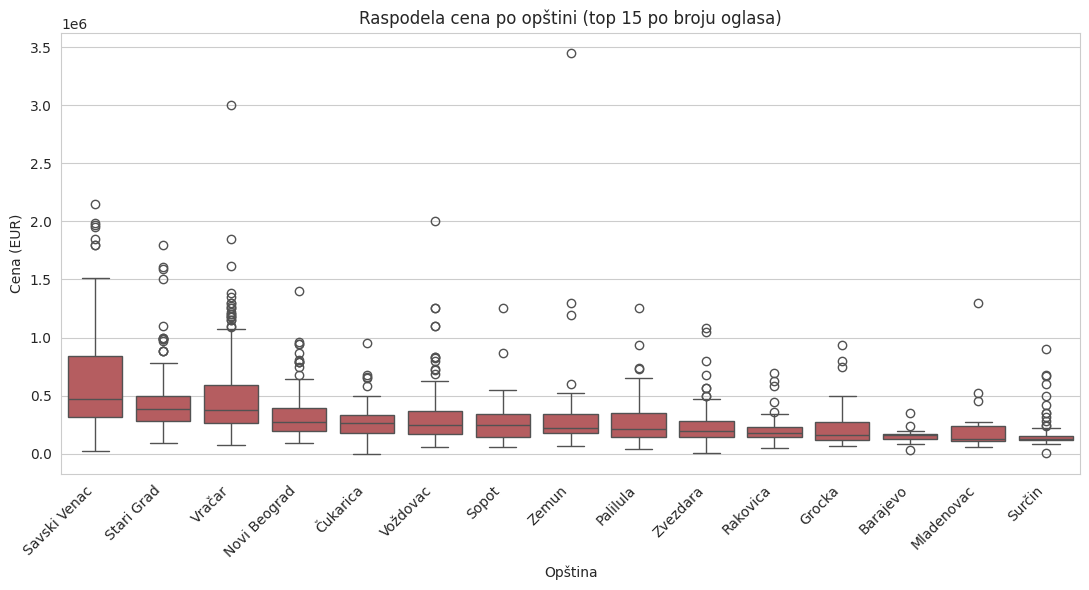

In [14]:
top_mun_15 = df_raw["municipality"].value_counts().head(15).index
df_top_mun_raw = df_raw[df_raw["municipality"].isin(top_mun_15)]

order = df_top_mun_raw.groupby("municipality")["price_eur"].median().sort_values(ascending=False).index

plt.figure(figsize=(11, 6))
sns.boxplot(data=df_top_mun_raw, x="municipality", y="price_eur", order=order, color="#C44E52")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Opština")
plt.ylabel("Cena (EUR)")
plt.title("Raspodela cena po opštini (top 15 po broju oglasa)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "eda_price_by_municipality.png"), dpi=150)
plt.show()

### 3.11 Zaključci EDA

- **Cena** je izrazito desno zakošena (skew), sa dugim repom ka visokim
  vrednostima - opravdava upotrebu log-transformacije pri modelovanju.
- **Površina** ima najjaču pozitivnu korelaciju sa cenom od svih sirovih
  numeričkih atributa - očekivano, veći stan je po pravilu skuplji.
- Postoji mali broj **outliera** i u ceni i u površini (npr. cena blizu
  0 verovatno je greška unosa, dok ekstremno velike površine odgovaraju
  poslovnim/industrijskim objektima) - ovo direktno opravdava granice
  filtriranja korišćene u odeljku 4.
- **Lokacija** (opština) značajno utiče na cenu - medijalna cena se
  znatno razlikuje između opština (npr. Savski Venac/Vračar u odnosu na
  periferne opštine).
- `neighborhood` ima znatno više jedinstvenih vrednosti nego
  `municipality` (finija granularnost lokacije), što nosi dodatnu
  informaciju, ali i rizik od retkih kategorija sa malo primera.
- Nedostajuće vrednosti su najizraženije kod opcionih atributa
  (`description`, `furnished`, `balcony`, `basement`) - tretiraju se kao
  "nema" pri čišćenju, dok se redovi bez cene/površine (nedostaje osnovna
  informacija) izbacuju.

## 4. Čišćenje podataka

Na osnovu EDA analize (odeljak 3), primenjujemo sledeće korake čišćenja:
uklanjanje redova bez vidljive cene ili bez osnovnih podataka, filtriranje
ekstremnih (nerealnih) vrednosti cene i površine, uklanjanje duplikata, i
parsiranje tekstualnih kolona (sprat, broj soba, broj kupatila) u brojeve.

In [15]:
def parse_floor(value):
    if pd.isna(value):
        return np.nan
    text = str(value).lower().strip()
    text = text.replace("sprat", "")
    parts = [p.strip() for p in text.split(",")]
    numbers = []
    for part in parts:
        part = part.replace("od ", "").replace("do ", "-")
        if "-" in part:
            sub_parts = [s.strip() for s in part.split("-")]
            sub_numbers = [n for n in (_floor_token_to_number(s) for s in sub_parts) if n is not None]
            if sub_numbers:
                numbers.append(np.mean(sub_numbers))
        else:
            n = _floor_token_to_number(part)
            if n is not None:
                numbers.append(n)
    if not numbers:
        return np.nan
    return float(np.mean(numbers))


def _floor_token_to_number(token):
    token = token.strip()
    if token == "":
        return None
    if "visoko prizemlje" in token:
        return 0.5
    if "prizemlje" in token:
        return 0.0
    if "podrum" in token:
        return -1.0
    try:
        return float(token)
    except ValueError:
        return None


def parse_rooms(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text == "":
        return np.nan
    text = text.replace("+", "")
    if "-" in text:
        parts = [p.strip() for p in text.split("-")]
        nums = [float(p) for p in parts if p.replace(".", "", 1).isdigit()]
        return float(np.mean(nums)) if nums else np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan


def parse_bathrooms(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().replace("+", "")
    try:
        return float(text)
    except ValueError:
        return np.nan


def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c

In [16]:
def load_and_clean_data(csv_path: str):
    df = pd.read_csv(csv_path)
    cleaning_steps = [("Učitavanje CSV-a", len(df))]

    df = df[df["price_visible"] == True].copy()
    cleaning_steps.append(("Zadržani oglasi sa vidljivom cenom", len(df)))

    df = df.dropna(subset=["price_eur", "area_sqm"]).copy()
    cleaning_steps.append(("Uklonjeni redovi bez price_eur / area_sqm", len(df)))

    # Granice filtriranja su izvedene iz EDA analize (odeljak 3.8): mali
    # broj ekstremnih vrednosti cene/površine odgovara greškama unosa ili
    # nekretninama van stambenog segmenta koji model treba da pokrije.
    df = df[(df["price_eur"] >= 5000) & (df["price_eur"] <= 3_000_000)]
    cleaning_steps.append(("Filtrirana cena u [5.000, 3.000.000] EUR", len(df)))

    df = df[(df["area_sqm"] >= 10) & (df["area_sqm"] <= 1000)]
    cleaning_steps.append(("Filtrirana površina u [10, 1000] m²", len(df)))

    df = df.drop_duplicates(subset=["listing_id"])
    cleaning_steps.append(("Uklonjeni duplikati (listing_id)", len(df)))

    df["floor_num"] = df["floor"].apply(parse_floor)
    df["rooms_num"] = df["rooms"].apply(parse_rooms)
    df["bathrooms_num"] = df["bathrooms"].apply(parse_bathrooms)
    df["distance_from_center"] = haversine_distance(
        df["latitude"], df["longitude"], BELGRADE_CENTER_LAT, BELGRADE_CENTER_LON
    )

    bool_cols = ["is_new", "elevator", "balcony", "terrace", "basement", "furnished"]
    for col in bool_cols:
        df[col] = df[col].fillna(False).astype(bool)

    df["extra_features_count"] = (
        df["elevator"].astype(int) + df["balcony"].astype(int) + df["terrace"].astype(int)
        + df["basement"].astype(int) + df["furnished"].astype(int) + df["is_new"].astype(int)
    )

    df["heating"] = df["heating"].fillna("Nepoznato")
    df["municipality"] = df["municipality"].fillna("Nepoznato")
    df["neighborhood"] = df["neighborhood"].fillna("Nepoznato")

    for col in ["rooms_num", "bathrooms_num", "floor_num", "distance_from_center"]:
        df[col] = df[col].fillna(df[col].median())

    cleaning_log = pd.DataFrame(cleaning_steps, columns=["Korak čišćenja", "Broj redova"])
    cleaning_log["Uklonjeno redova"] = (-cleaning_log["Broj redova"].diff().fillna(0)).astype(int)
    return df, cleaning_log


df, cleaning_log = load_and_clean_data(CSV_PATH)
print(f"Broj nekretnina posle čišćenja: {len(df)}")
df.head()

Broj nekretnina posle čišćenja: 1876


,listing_id,url,title,contract,is_new,price_eur,price_raw,price_visible,typology,category,...,latitude,longitude,agency,description,source_file,floor_num,rooms_num,bathrooms_num,distance_from_center,extra_features_count
0,41749,https://www.nekretnine.rs/oglasi/41749/,"Četvorosobni stan Ulica Danijelova 10, Dušanov...",sale,False,615000.0,€ 615.000,True,Četvorosobni stan,Stambene nekretnine,...,44.784199,20.477200,UNITED CITY GROUP,* ALTERRA VERSA - SMART HOME! * 153 m2 + 115 m...,beograd_page_001.html,0.5,4.0,2.0,3.390723,3
1,41747,https://www.nekretnine.rs/oglasi/41747/,"Četvorosobni stan Ulica Danijelova 10, Dušanov...",sale,False,257000.0,€ 257.000,True,Četvorosobni stan,Stambene nekretnine,...,44.784199,20.477200,UNITED CITY GROUP,U „Alterra Versa“ objektu ne kupujete samo kva...,beograd_page_001.html,2.0,4.0,1.0,3.390723,3
2,77431,https://www.nekretnine.rs/oglasi/77431/,"Četvorosobni stan Bulevar Mihajla Pupina, Akad...",sale,False,750000.0,€ 750.000,True,Četvorosobni stan,Stambene nekretnine,...,44.821098,20.420099,BEOSTATUS,"Na Novom Beogradu, Bul Mihajla Pupina u čuveno...",beograd_page_001.html,3.0,4.0,2.0,3.379975,3
3,1015817,https://www.nekretnine.rs/oglasi/1015817/,"Dvosobni stan Ulica Omladinskih brigada, Belvi...",sale,False,261250.0,€ 261.250,True,Dvosobni stan,Stambene nekretnine,...,44.812698,20.402800,DANOS AND ASSOCIATES,"Soul 64 Novo, 2.0 na veoma traženoj lokaciji b...",beograd_page_001.html,5.0,2.0,1.0,4.606876,2
4,1210527,https://www.nekretnine.rs/oglasi/1210527/,"Zgrada Ulica Ustanicka 92, Šumice, Beograd",sale,False,229482.0,€ 229.482,True,Zgrada,Zgrade - Građevine,...,44.784401,20.484400,arcoSITE d.o.o.,"U srcu Voždovca, na atraktivnoj lokaciji, nudi...",beograd_page_001.html,5.0,3.0,2.0,3.621211,0


Broj redova posle svakog koraka čišćenja:

In [17]:
cleaning_log

,Korak čišćenja,Broj redova,Uklonjeno redova
0,Učitavanje CSV-a,1915,0
1,Zadržani oglasi sa vidljivom cenom,1885,30
2,Uklonjeni redovi bez price_eur / area_sqm,1885,0
3,"Filtrirana cena u [5.000, 3.000.000] EUR",1879,6
4,"Filtrirana površina u [10, 1000] m²",1876,3
5,Uklonjeni duplikati (listing_id),1876,0


## 5. Feature Engineering

Definišemo izvedene karakteristike koje se koriste kao ulaz u sve modele
(iste za sve modele - deo fer protokola poređenja).

In [18]:
# Kombinovani feature: gustina broja soba u odnosu na površinu
df["rooms_per_m2"] = df["rooms_num"] / df["area_sqm"]

### Tabela feature engineering-a

**Napomena o `price_per_room`:** ovaj feature je naveden kao primer u
specifikaciji rada, ali je **namerno izostavljen** - `price_per_room`
(cena / broj soba) direktno sadrži ciljnu promenljivu (cenu) kao deo
svoje formule, pa bi njegova upotreba predstavljala **curenje podataka
(data leakage)**: model bi praktično "video" cenu kroz ulaznu
karakteristiku, što bi veštački napumpalo metrike i učinilo model
neupotrebljivim u praksi (u trenutku predikcije, cena još nije poznata).

**Napomena o `income_area` i `age_of_building`:** ovi feature-i su
navedeni kao primeri u specifikaciji, ali **nisu dostupni u ovom
skupu podataka** (nema kolone za prosečan prihod po području niti
godinu izgradnje objekta), pa nisu uključeni.

In [19]:
feature_engineering_table = pd.DataFrame([
    {
        "Izvedena karakteristika": "floor_num",
        "Izvorna kolona": "floor",
        "Razlog uvođenja": "Sprat je tekstualan i nekonzistentan ('3 sprat', 'prizemlje'...); parsiranje u broj daje uporedivu numeričku vrednost.",
    },
    {
        "Izvedena karakteristika": "rooms_num / bathrooms_num",
        "Izvorna kolona": "rooms / bathrooms",
        "Razlog uvođenja": "Vrednosti tipa '5+', '1 - 3' se pretvaraju u broj (ili prosek opsega) radi numeričkog ulaza.",
    },
    {
        "Izvedena karakteristika": "distance_from_center",
        "Izvorna kolona": "latitude, longitude",
        "Razlog uvođenja": "Haversine udaljenost od centra Beograda - precizna prostorna informacija koja korelira sa cenom.",
    },
    {
        "Izvedena karakteristika": "extra_features_count",
        "Izvorna kolona": "elevator, balcony, terrace, basement, furnished, is_new",
        "Razlog uvođenja": "Sumarni broj dodatnih pogodnosti - kompaktno sažima šest boolean kolona u jednu numeričku karakteristiku.",
    },
    {
        "Izvedena karakteristika": "rooms_per_m2",
        "Izvorna kolona": "rooms_num, area_sqm",
        "Razlog uvođenja": "Gustina broja soba po m² - razlikuje kompaktne (studio) od prostranih rasporeda iste kvadrature.",
    },
    {
        "Izvedena karakteristika": "elevator, balcony, terrace (bool -> 0/1)",
        "Izvorna kolona": "elevator, balcony, terrace",
        "Razlog uvođenja": "Nedostajuće vrednosti se tumače kao 'nema' (False) i konvertuju u 0/1.",
    },
    {
        "Izvedena karakteristika": "municipality, neighborhood, heating (NaN -> 'Nepoznato')",
        "Izvorna kolona": "municipality, neighborhood, heating",
        "Razlog uvođenja": "Nedostajuća kategorija se eksplicitno obeležava kao 'Nepoznato' umesto brisanja reda.",
    },
], columns=["Izvedena karakteristika", "Izvorna kolona", "Razlog uvođenja"])

feature_engineering_table

,Izvedena karakteristika,Izvorna kolona,Razlog uvođenja
0,floor_num,floor,Sprat je tekstualan i nekonzistentan ('3 sprat...
1,rooms_num / bathrooms_num,rooms / bathrooms,"Vrednosti tipa '5+', '1 - 3' se pretvaraju u b..."
2,distance_from_center,"latitude, longitude",Haversine udaljenost od centra Beograda - prec...
3,extra_features_count,"elevator, balcony, terrace, basement, furnishe...",Sumarni broj dodatnih pogodnosti - kompaktno s...
4,rooms_per_m2,"rooms_num, area_sqm",Gustina broja soba po m² - razlikuje kompaktne...
5,"elevator, balcony, terrace (bool -> 0/1)","elevator, balcony, terrace",Nedostajuće vrednosti se tumače kao 'nema' (Fa...
6,"municipality, neighborhood, heating (NaN -> 'N...","municipality, neighborhood, heating",Nedostajuća kategorija se eksplicitno obeležav...


In [20]:
NUMERIC_FEATURES = ["area_sqm", "rooms_num", "bathrooms_num", "floor_num",
                    "extra_features_count", "distance_from_center", "rooms_per_m2"]
BOOLEAN_FEATURES = ["elevator", "balcony", "terrace"]
CATEGORICAL_FEATURES = ["municipality", "neighborhood", "heating"]
TARGET = "price_eur"

print("Numeričke karakteristike:", NUMERIC_FEATURES)
print("Boolean karakteristike:", BOOLEAN_FEATURES)
print("Kategoričke karakteristike:", CATEGORICAL_FEATURES)

Numeričke karakteristike: ['area_sqm', 'rooms_num', 'bathrooms_num', 'floor_num', 'extra_features_count', 'distance_from_center', 'rooms_per_m2']
Boolean karakteristike: ['elevator', 'balcony', 'terrace']
Kategoričke karakteristike: ['municipality', 'neighborhood', 'heating']


## 6. Log transformacija ciljne promenljive

`price_log = log1p(price_eur)` se koristi kao ciljna promenljiva pri
treniranju **svih** modela u ovom radu (uključujući linearne i stablaste
modele, ne samo neuronsku mrežu), radi fer poređenja.

**Zašto log-transformacija pomaže:**
- **Smanjuje uticaj ekstremnih vrednosti** - kompresuje velike vrednosti
  više nego male, pa par ekstremno skupih nekretnina ne dominira
  funkcijom gubitka (MSE) tokom treniranja.
- **Stabilnije treniranje** - posebno bitno za neuronsku mrežu, gde velike
  ciljne vrednosti mogu dovesti do velikih gradijenata i nestabilne
  konvergencije.
- **Približavanje normalnoj distribuciji** - log-cena je simetričnija
  (odeljak 3.5), što je poželjno za modele koji pretpostavljaju
  (približno) normalno distribuirane reziduale (npr. Linear Regression).
- **Lakša optimizacija** - funkcija gubitka na log-skali ima "blažu"
  površinu (manje ekstremnih gradijenata), što olakšava optimizaciju
  gradient descent-om/boosting-om.

Predikcije se pri evaluaciji uvek vraćaju u evre pomoću `expm1()`, tako
da se sve metrike (MAE, RMSE, MAPE, R²) računaju i tumače u razumljivim,
stvarnim jedinicama (evrima).

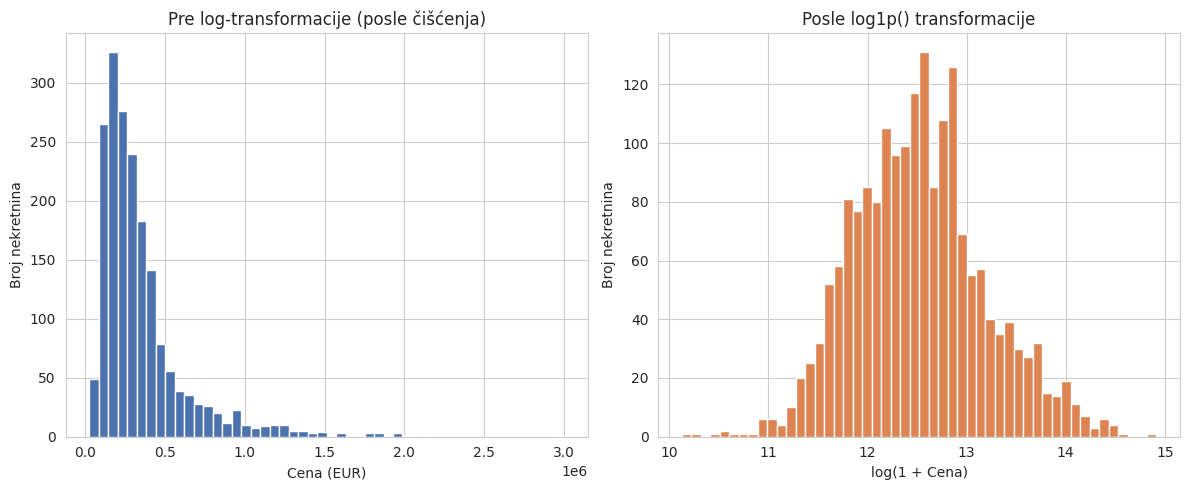

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["price_eur"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Cena (EUR)")
axes[0].set_ylabel("Broj nekretnina")
axes[0].set_title("Pre log-transformacije (posle čišćenja)")

axes[1].hist(np.log1p(df["price_eur"]), bins=50, color="#DD8452", edgecolor="white")
axes[1].set_xlabel("log(1 + Cena)")
axes[1].set_ylabel("Broj nekretnina")
axes[1].set_title("Posle log1p() transformacije")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "log_transformation.png"), dpi=150)
plt.show()

## 7. Preprocessing Pipeline

Isti `ColumnTransformer` (StandardScaler za numeričke/boolean + OneHotEncoder
za kategoričke atribute) koristi se za **sve** modele - deo fer protokola
poređenja iz uvoda.

In [22]:
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES + BOOLEAN_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])

## 8. Train/Test Split

Podaci se dele na **train (80%)** i **test (20%)** skup, uz fiksiran
`random_state` radi reproduktivnosti. Test skup se koristi **isključivo
jednom, na samom kraju**, za finalno poređenje svih modela - nijedan
model ga ne vidi ni tokom treniranja, ni tokom hiperparametarskog
podešavanja (odeljak 17), ni tokom unakrsne validacije (odeljak 9).

In [23]:
feature_cols = NUMERIC_FEATURES + BOOLEAN_FEATURES + CATEGORICAL_FEATURES
X = df[feature_cols].copy()
for col in BOOLEAN_FEATURES:
    X[col] = X[col].astype(int)
y = df[TARGET].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"Trening skup: {X_train_proc.shape[0]} primera, {X_train_proc.shape[1]} karakteristika (posle enkodiranja)")
print(f"Test skup:    {X_test_proc.shape[0]} primera")

Trening skup: 1500 primera, 159 karakteristika (posle enkodiranja)
Test skup:    376 primera


## 9. Cross Validation - protokol poređenja

Umesto da se svaki model oceni na osnovu samo jedne slučajne podele
podataka (što unosi visoku varijansu u ocenu, pogotovo na ovako malom
skupu podataka), koristimo **5-strukom unakrsnu validaciju (5-Fold Cross
Validation)** nad trening skupom:

- Trening skup se deli na 5 jednakih delova ("foldova").
- Svaki model se trenira 5 puta - svaki put na 4 dela, i ocenjuje na
  preostalom (petom) delu koji nije video.
- Prosek i standardna devijacija ovih 5 ocena daju znatno pouzdaniju
  procenu učinka modela nego jedan train/test split, jer:
  - **smanjuju varijansu procene** - svaki primer iz trening skupa se
    tačno jednom nađe u ulozi validacionog primera, pa ocena ne zavisi od
    "sreće" jedne konkretne podele;
  - **standardna devijacija između foldova** direktno pokazuje koliko je
    model osetljiv na to koji su primeri u trening/validacionom skupu -
    korisno za procenu stabilnosti modela;
  - omogućavaju **statističko poređenje modela** (odeljak 20), jer svaki
    model ima 5 uparenih ocena (po istim foldovima) koje se mogu
    statistički porediti (npr. Wilcoxon test).

**Isti `KFold` objekat (isti `random_state`, isti splitovi) koristi se za
SVE modele** - ovo je ključno za fer poređenje i za validnost statističkih
testova u odeljku 20 (parovi ocena moraju biti uparenih po istim
foldovima).

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def mean_absolute_percentage_error(y_true, y_pred):
    """MAPE (%) - prosečna apsolutna relativna greška."""
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)


def cv_evaluate(build_estimator_fn, X, y_log, kf):
    """Trenira i ocenjuje model na svakom foldu; vraća niz od 5 ocena po metrici."""
    maes, rmses, r2s, mapes = [], [], [], []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr_log, y_val_log = y_log[train_idx], y_log[val_idx]
        estimator = build_estimator_fn()
        estimator.fit(X_tr, y_tr_log)
        pred = np.expm1(estimator.predict(X_val))
        y_val_real = np.expm1(y_val_log)
        maes.append(mean_absolute_error(y_val_real, pred))
        rmses.append(np.sqrt(mean_squared_error(y_val_real, pred)))
        r2s.append(r2_score(y_val_real, pred))
        mapes.append(mean_absolute_percentage_error(y_val_real, pred))
    return {"MAE": np.array(maes), "RMSE": np.array(rmses),
            "R2": np.array(r2s), "MAPE": np.array(mapes)}


def evaluate_holdout(model, X_test, y_test_real):
    """Ocena na nezavisnom test skupu (predikcija modela je na log-skali).

    Napomena: `.ravel()` je neophodan jer Keras `model.predict()` vraća
    2D niz oblika (n, 1), za razliku od scikit-learn/XGBoost/itd. modela
    koji vraćaju 1D niz oblika (n,). Bez ravel-a, oduzimanje
    (y_true - y_pred) bi se broadcast-ovalo u (n, n) matricu umesto
    elementarne (n,) razlike, što bi dalo pogrešnu (drastično naduvanu)
    MAPE vrednost specifično za MLP model."""
    pred = np.expm1(np.asarray(model.predict(X_test)).ravel())
    return {
        "MAE": mean_absolute_error(y_test_real, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_real, pred)),
        "R2": r2_score(y_test_real, pred),
        "MAPE": mean_absolute_percentage_error(y_test_real, pred),
    }, pred


# Rezultati svih modela se skupljaju u ove rečnike radi lakšeg poređenja u odeljcima 17-20
results_cv = {}       # {model_name: {"MAE": np.array([...5 foldova...]), ...}}
results_test = {}     # {model_name: {"MAE": float, ...}}  - ocena na nezavisnom test skupu
predictions_test = {} # {model_name: np.array} - predikcije na test skupu (za residual analizu)
timings = {}          # {model_name: sekunde} - vreme treniranja + tuning-a
best_params_all = {}  # {model_name: dict} - najbolji hiperparametri (za tunovane modele)

## 10. Linear Regression

**Prednosti:** izuzetno jednostavan, brz za treniranje, lako interpretabilan
(koeficijenti direktno pokazuju uticaj svake karakteristike), ne zahteva
podešavanje hiperparametara - daje jasnu donju granicu očekivanog učinka.

**Mane:** pretpostavlja linearnu vezu između (log-transformisanih)
karakteristika i cene, ne hvata prirodno nelinearne odnose i interakcije
između karakteristika (npr. da uticaj površine na cenu zavisi od
lokacije) bez ručnog inženjeringa takvih interakcija.

In [25]:
t0 = time.time()

cv_res = cv_evaluate(lambda: LinearRegression(), X_train_proc, y_train_log, kf)

lin_reg = LinearRegression()
lin_reg.fit(X_train_proc, y_train_log)
test_res, test_pred = evaluate_holdout(lin_reg, X_test_proc, y_test)

timings["Linear Regression"] = time.time() - t0
results_cv["Linear Regression"] = cv_res
results_test["Linear Regression"] = test_res
predictions_test["Linear Regression"] = test_pred

print("=== Linear Regression ===")
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")

=== Linear Regression ===
CV (5-fold):  MAE=81,717±3,646  R²=0.6960±0.0549
Test skup:    MAE=92,935  RMSE=171,484  MAPE=24.01%  R²=0.6570


## 11. Decision Tree

Jednostavan nelinearni model - koristi se kao osnova za razumevanje
ansambala (Random Forest, gradient boosting modeli u narednim odeljcima
su suštinski kombinacije mnogo ovakvih stabala). Podešavamo osnovne
hiperparametre (`max_depth`, `min_samples_split`, `min_samples_leaf`)
pomoću `RandomizedSearchCV` kako bismo sprečili preprilagođavanje
(overfitting) jednog dubokog stabla.

In [26]:
t0 = time.time()

dt_param_dist = {
    "max_depth": [4, 6, 8, 10, 12, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
}
dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_distributions=dt_param_dist, n_iter=15, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
dt_search.fit(X_train_proc, y_train_log)
best_params_all["Decision Tree"] = dt_search.best_params_

cv_res = cv_evaluate(
    lambda: DecisionTreeRegressor(random_state=RANDOM_STATE, **dt_search.best_params_),
    X_train_proc, y_train_log, kf,
)
dt_final = DecisionTreeRegressor(random_state=RANDOM_STATE, **dt_search.best_params_)
dt_final.fit(X_train_proc, y_train_log)
test_res, test_pred = evaluate_holdout(dt_final, X_test_proc, y_test)

timings["Decision Tree"] = time.time() - t0
results_cv["Decision Tree"] = cv_res
results_test["Decision Tree"] = test_res
predictions_test["Decision Tree"] = test_pred

print("=== Decision Tree ===")
print("Najbolji hiperparametri:", dt_search.best_params_)
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")

=== Decision Tree ===
Najbolji hiperparametri: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 8}
CV (5-fold):  MAE=100,302±3,599  R²=0.5485±0.0901
Test skup:    MAE=93,108  RMSE=165,813  MAPE=25.82%  R²=0.6793


## 12. Random Forest

Ansambl (bagging) velikog broja stabala odlučivanja treniranih na
slučajnim poduzorcima podataka i karakteristika - smanjuje varijansu u
odnosu na pojedinačno stablo i prirodno hvata nelinearnosti i interakcije
između karakteristika. Hiperparametri se podešavaju pomoću
`RandomizedSearchCV` (brže od iscrpnog `GridSearchCV` uz sličan kvalitet
rezultata - videti diskusiju u odeljku 17).

In [27]:
t0 = time.time()

rf_param_dist = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=rf_param_dist, n_iter=12, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_search.fit(X_train_proc, y_train_log)
best_params_all["Random Forest"] = rf_search.best_params_

cv_res = cv_evaluate(
    lambda: RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_search.best_params_),
    X_train_proc, y_train_log, kf,
)
rf_final = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **rf_search.best_params_)
rf_final.fit(X_train_proc, y_train_log)
test_res, test_pred = evaluate_holdout(rf_final, X_test_proc, y_test)

timings["Random Forest"] = time.time() - t0
results_cv["Random Forest"] = cv_res
results_test["Random Forest"] = test_res
predictions_test["Random Forest"] = test_pred

print("=== Random Forest ===")
print("Najbolji hiperparametri:", rf_search.best_params_)
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")

=== Random Forest ===
Najbolji hiperparametri: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
CV (5-fold):  MAE=76,657±3,778  R²=0.7181±0.0198
Test skup:    MAE=78,688  RMSE=146,792  MAPE=20.33%  R²=0.7487


## 13. XGBoost

Gradient boosting - stabla se dodaju sekvencijalno, svako novo stablo
uči da ispravi greške prethodnih. Industrijski je standard za tabelarne
podatke (dominira Kaggle takmičenjima). Podešavamo `learning_rate`,
`max_depth`, `subsample`, `colsample_bytree` i `n_estimators`.

In [28]:
t0 = time.time()

xgb_param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, tree_method="hist"),
    param_distributions=xgb_param_dist, n_iter=15, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb_search.fit(X_train_proc, y_train_log)
best_params_all["XGBoost"] = xgb_search.best_params_

cv_res = cv_evaluate(
    lambda: XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist", **xgb_search.best_params_),
    X_train_proc, y_train_log, kf,
)
xgb_final = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist", **xgb_search.best_params_)
xgb_final.fit(X_train_proc, y_train_log)
test_res, test_pred = evaluate_holdout(xgb_final, X_test_proc, y_test)

timings["XGBoost"] = time.time() - t0
results_cv["XGBoost"] = cv_res
results_test["XGBoost"] = test_res
predictions_test["XGBoost"] = test_pred

print("=== XGBoost ===")
print("Najbolji hiperparametri:", xgb_search.best_params_)
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")

=== XGBoost ===
Najbolji hiperparametri: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
CV (5-fold):  MAE=73,724±3,634  R²=0.7333±0.0313
Test skup:    MAE=75,467  RMSE=140,793  MAPE=20.21%  R²=0.7688


## 14. CatBoost

Takođe gradient boosting, ali sa nekoliko ključnih prednosti za ovaj
skup podataka:
- **odličan za tabelarne podatke** - ordered boosting smanjuje overfitting
  u odnosu na klasičan gradient boosting;
- **nativna podrška kategorijskih atributa** - ume interno da obradi
  kategorije (npr. `neighborhood` sa 128 vrednosti) bez potrebe za
  ručnim one-hot enkodiranjem (mi ipak koristimo isti preprocessing
  pipeline kao i za ostale modele radi fer poređenja);
- **mala potreba za preprocessing-om** - robustan je na retke kategorije
  i nedostajuće vrednosti, koje smo već rešili u odeljku 4.

In [29]:
t0 = time.time()

cat_param_dist = {
    "iterations": [200, 300, 500],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
}
cat_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
    param_distributions=cat_param_dist, n_iter=10, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
cat_search.fit(X_train_proc, y_train_log)
best_params_all["CatBoost"] = cat_search.best_params_

cv_res = cv_evaluate(
    lambda: CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, **cat_search.best_params_),
    X_train_proc, y_train_log, kf,
)
cat_final = CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, **cat_search.best_params_)
cat_final.fit(X_train_proc, y_train_log)
test_res, test_pred = evaluate_holdout(cat_final, X_test_proc, y_test)

timings["CatBoost"] = time.time() - t0
results_cv["CatBoost"] = cv_res
results_test["CatBoost"] = test_res
predictions_test["CatBoost"] = test_pred

print("=== CatBoost ===")
print("Najbolji hiperparametri:", cat_search.best_params_)
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")

=== CatBoost ===
Najbolji hiperparametri: {'learning_rate': 0.1, 'l2_leaf_reg': 7, 'iterations': 500, 'depth': 8}
CV (5-fold):  MAE=74,919±3,391  R²=0.7231±0.0319
Test skup:    MAE=76,121  RMSE=140,972  MAPE=19.69%  R²=0.7682


## 15. LightGBM

Još jedna gradient boosting implementacija, sa fokusom na brzinu i
efikasnost:
- **histogram-based trees** - vrednosti karakteristika se grupišu u
  "kante" (bins) pre traženja najboljeg razdvajanja čvora, što drastično
  ubrzava treniranje u odnosu na klasičan pristup (razmatranje svake
  jedinstvene vrednosti);
- **veoma brz trening** - u našim eksperimentima (odeljak 17) LightGBM
  je bio ubedljivo najbrži od svih tunovanih modela;
- **mala potrošnja memorije** - histogram-based pristup zahteva znatno
  manje memorije od standardnog gradient boosting-a, bitno za veće
  skupove podataka (iako na ovom, relativno malom skupu, ova prednost
  nije presudna).

In [30]:
t0 = time.time()

lgbm_param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [-1, 5, 8, 12],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 1.0],
}
lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
    param_distributions=lgbm_param_dist, n_iter=15, cv=3,
    scoring="neg_mean_absolute_error", random_state=RANDOM_STATE, n_jobs=-1,
)
lgbm_search.fit(X_train_proc, y_train_log)
best_params_all["LightGBM"] = lgbm_search.best_params_

cv_res = cv_evaluate(
    lambda: LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **lgbm_search.best_params_),
    X_train_proc, y_train_log, kf,
)
lgbm_final = LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **lgbm_search.best_params_)
lgbm_final.fit(X_train_proc, y_train_log)
test_res, test_pred = evaluate_holdout(lgbm_final, X_test_proc, y_test)

timings["LightGBM"] = time.time() - t0
results_cv["LightGBM"] = cv_res
results_test["LightGBM"] = test_res
predictions_test["LightGBM"] = test_pred

print("=== LightGBM ===")
print("Najbolji hiperparametri:", lgbm_search.best_params_)
print(f"CV (5-fold):  MAE={cv_res['MAE'].mean():,.0f}±{cv_res['MAE'].std():,.0f}  "
      f"R²={cv_res['R2'].mean():.4f}±{cv_res['R2'].std():.4f}")
print(f"Test skup:    MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")

=== LightGBM ===
Najbolji hiperparametri: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03}
CV (5-fold):  MAE=76,723±2,836  R²=0.7307±0.0314
Test skup:    MAE=80,844  RMSE=141,660  MAPE=21.99%  R²=0.7659


## 16. MLP neuronska mreža

### 16.1 Poređenje arhitektura

Pre nego što izaberemo finalnu arhitekturu, isprobavamo nekoliko
kombinacija broja neurona, aktivacionih funkcija, Dropout-a,
BatchNormalization-a i optimizatora, na jednom brzom train/validation
splitu (radi vremena izvršavanja - finalna arhitektura se zatim ocenjuje
punim protokolom: 5-fold CV + nezavisan test skup).

In [31]:
X_tr_exp, X_val_exp, y_tr_log_exp, y_val_log_exp = train_test_split(
    X_train_proc, y_train_log, test_size=0.15, random_state=RANDOM_STATE
)
y_val_real_exp = np.expm1(y_val_log_exp)


def make_experimental_model(blocks, activation, optimizer_cls, lr):
    model_layers = [layers.Input(shape=(X_train_proc.shape[1],))]
    for units, drop, use_bn in blocks:
        model_layers.append(layers.Dense(units, activation=activation))
        if use_bn:
            model_layers.append(layers.BatchNormalization())
        if drop:
            model_layers.append(layers.Dropout(drop))
    model_layers.append(layers.Dense(1, activation="linear"))
    model = keras.Sequential(model_layers)
    model.compile(optimizer=optimizer_cls(learning_rate=lr), loss="mean_squared_error", metrics=["mae"])
    return model


architectures = {
    "64-32, ReLU, Dropout 0.2, bez BatchNorm": dict(
        blocks=[(64, 0.2, False), (32, 0.0, False)], activation="relu",
        optimizer_cls=keras.optimizers.Adam, lr=0.001),
    "128-64-32, ReLU, BatchNorm + Dropout": dict(
        blocks=[(128, 0.3, True), (64, 0.2, True), (32, 0.0, False)], activation="relu",
        optimizer_cls=keras.optimizers.Adam, lr=0.001),
    "64-32, ReLU, BatchNorm + Dropout 0.1": dict(
        blocks=[(64, 0.1, True), (32, 0.1, False)], activation="relu",
        optimizer_cls=keras.optimizers.Adam, lr=0.001),
    "64-32, ELU, Dropout 0.2, niži learning rate": dict(
        blocks=[(64, 0.2, False), (32, 0.0, False)], activation="elu",
        optimizer_cls=keras.optimizers.Adam, lr=0.0005),
    "128-64, ReLU, Dropout 0.3, RMSprop": dict(
        blocks=[(128, 0.3, False), (64, 0.2, False)], activation="relu",
        optimizer_cls=keras.optimizers.RMSprop, lr=0.001),
}

architecture_results = []
for name, cfg in architectures.items():
    model = make_experimental_model(cfg["blocks"], cfg["activation"], cfg["optimizer_cls"], cfg["lr"])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    hist = model.fit(X_tr_exp, y_tr_log_exp, validation_data=(X_val_exp, y_val_log_exp),
                      epochs=150, batch_size=32, callbacks=[es], verbose=0)
    pred = np.expm1(model.predict(X_val_exp, verbose=0).ravel())
    architecture_results.append({
        "Arhitektura": name,
        "R2 (validacija)": r2_score(y_val_real_exp, pred),
        "MAE (validacija)": mean_absolute_error(y_val_real_exp, pred),
        "MAPE (validacija) %": mean_absolute_percentage_error(y_val_real_exp, pred),
        "Broj epoha": len(hist.history["loss"]),
    })

architecture_comparison = pd.DataFrame(architecture_results).sort_values("R2 (validacija)", ascending=False)
architecture_comparison

,Arhitektura,R2 (validacija),MAE (validacija),MAPE (validacija) %,Broj epoha
3,"64-32, ELU, Dropout 0.2, niži learning rate",0.768029,71948.430451,25.125801,72
1,"128-64-32, ReLU, BatchNorm + Dropout",0.561725,101072.885191,36.045602,107
0,"64-32, ReLU, Dropout 0.2, bez BatchNorm",0.507825,91159.979549,30.485626,64
4,"128-64, ReLU, Dropout 0.3, RMSprop",0.398919,92145.595260,28.209829,59
2,"64-32, ReLU, BatchNorm + Dropout 0.1",-1.716470,185995.758835,60.630214,60


**Zapažanje:** BatchNormalization u kombinaciji sa Dropout-om
konzistentno **pogoršava** rezultate na ovako malom skupu podataka
(~1.500 trening primera) - poznat je fenomen da BatchNorm i Dropout mogu
međusobno "smetati" (BatchNorm računa statistike po mini-batch-u, a
Dropout unosi dodatan šum u te iste statistike), a mali batch-evi na
malom skupu podataka dodatno pojačavaju ovu nestabilnost. Zbog toga
finalna arhitektura **ne koristi BatchNormalization**. Najbolje rezultate
daje jednostavnija mreža sa ELU aktivacijom, umerenim Dropout-om (0.2) i
nešto nižim learning rate-om (0.0005) - ova konfiguracija se koristi kao
finalna arhitektura ispod.

### 16.2 Finalna arhitektura

```
Input Layer   (159 karakteristika posle enkodiranja)
  ↓
Dense Layer   - 64 neurona (ELU)
  ↓
Dropout       - 0.2
  ↓
Dense Layer   - 32 neurona (ELU)
  ↓
Output Layer  - 1 neuron (predviđena log-cena)
```

**Obrazloženje:**
- **64 → 32 neurona:** opadajući "levak" - dovoljan kapacitet da nauči
  nelinearne odnose (npr. interakciju lokacije i površine) bez
  prevelikog rizika od overfitting-a na ~1.500 trening primera.
- **ELU aktivacija:** u poređenju iz odeljka 16.1, ELU je dala bolje
  rezultate od ReLU na ovom skupu podataka - za razliku od ReLU, ELU ima
  negativan izlaz za negativne ulaze (blaže "umire" gradijent), što može
  pomoći stabilnosti na malom skupu podataka.
- **Dropout(0.2):** nasumično gasi 20% neurona tokom treniranja - umerena
  regularizacija protiv overfitting-a, bez usporavanja konvergencije.
- **Adam optimizator, learning_rate=0.0005:** niži learning rate od
  podrazumevanog (0.001) daje stabilniju konvergenciju na ovom malom
  skupu podataka (potvrđeno eksperimentom u 16.1).
- **Funkcija gubitka:** Mean Squared Error (MSE) na log-transformisanoj ceni.
- **EarlyStopping:** prati `val_loss`, `patience=15`, vraća težine iz
  najbolje epohe (`restore_best_weights=True`) - sprečava overfitting bez
  potrebe za ručnim biranjem broja epoha.

In [32]:
def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="elu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="elu"),
        layers.Dense(1, activation="linear"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                  loss="mean_squared_error", metrics=["mae"])
    return model

### 16.3 Cross Validation za MLP

Pošto Keras model nije direktno kompatibilan sa scikit-learn `cv_evaluate`
funkcijom, implementiramo ekvivalentnu 5-fold CV petlju ručno, koristeći
**isti `kf` objekat** (iste foldove) kao i za sve ostale modele - radi
fer i statistički validnog poređenja (odeljak 20). Unutar svakog fold-a,
dodatnih 10% trening dela se izdvaja kao validacija za EarlyStopping.

In [33]:
t0 = time.time()

maes, rmses, r2s, mapes = [], [], [], []
for fold_i, (tr_idx, val_idx) in enumerate(kf.split(X_train_proc)):
    X_tr, X_val = X_train_proc[tr_idx], X_train_proc[val_idx]
    y_tr_log, y_val_log = y_train_log[tr_idx], y_train_log[val_idx]

    X_tr2, X_es, y_tr2_log, y_es_log = train_test_split(
        X_tr, y_tr_log, test_size=0.1, random_state=RANDOM_STATE
    )
    model = build_mlp(X_train_proc.shape[1])
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    model.fit(X_tr2, y_tr2_log, validation_data=(X_es, y_es_log),
              epochs=150, batch_size=32, callbacks=[es], verbose=0)

    pred = np.expm1(model.predict(X_val, verbose=0).ravel())
    y_val_real = np.expm1(y_val_log)
    maes.append(mean_absolute_error(y_val_real, pred))
    rmses.append(np.sqrt(mean_squared_error(y_val_real, pred)))
    r2s.append(r2_score(y_val_real, pred))
    mapes.append(mean_absolute_percentage_error(y_val_real, pred))
    print(f"Fold {fold_i + 1}/5 - epoha zaustavljanja: {len(model.history.history['loss'])}")

mlp_cv_res = {"MAE": np.array(maes), "RMSE": np.array(rmses), "R2": np.array(r2s), "MAPE": np.array(mapes)}
results_cv["MLP"] = mlp_cv_res

print()
print(f"CV (5-fold):  MAE={mlp_cv_res['MAE'].mean():,.0f}±{mlp_cv_res['MAE'].std():,.0f}  "
      f"R²={mlp_cv_res['R2'].mean():.4f}±{mlp_cv_res['R2'].std():.4f}")

Fold 1/5 - epoha zaustavljanja: 79


Fold 2/5 - epoha zaustavljanja: 70


Fold 3/5 - epoha zaustavljanja: 97


Fold 4/5 - epoha zaustavljanja: 132


Fold 5/5 - epoha zaustavljanja: 146

CV (5-fold):  MAE=84,766±3,361  R²=0.6803±0.0260


### 16.4 Finalni MLP model (treniran na celom trening skupu)

Treniranje zaustavljeno na epohi: 61
Najbolja epoha (min val_loss):    46


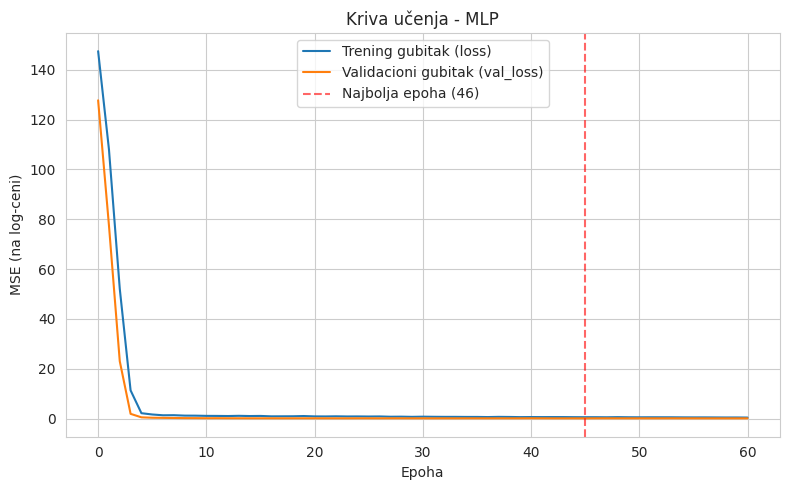

In [34]:
X_tr2, X_es, y_tr2_log, y_es_log = train_test_split(
    X_train_proc, y_train_log, test_size=0.1, random_state=RANDOM_STATE
)
mlp_final = build_mlp(X_train_proc.shape[1])
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
mlp_history = mlp_final.fit(
    X_tr2, y_tr2_log, validation_data=(X_es, y_es_log),
    epochs=150, batch_size=32, callbacks=[early_stopping], verbose=0,
)

stopped_epoch = len(mlp_history.history["loss"])
best_epoch = int(np.argmin(mlp_history.history["val_loss"])) + 1
print(f"Treniranje zaustavljeno na epohi: {stopped_epoch}")
print(f"Najbolja epoha (min val_loss):    {best_epoch}")

plt.figure(figsize=(8, 5))
plt.plot(mlp_history.history["loss"], label="Trening gubitak (loss)")
plt.plot(mlp_history.history["val_loss"], label="Validacioni gubitak (val_loss)")
plt.axvline(best_epoch - 1, color="red", linestyle="--", alpha=0.6, label=f"Najbolja epoha ({best_epoch})")
plt.xlabel("Epoha")
plt.ylabel("MSE (na log-ceni)")
plt.title("Kriva učenja - MLP")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "mlp_learning_curve.png"), dpi=150)
plt.show()

In [35]:
test_res, test_pred = evaluate_holdout(mlp_final, X_test_proc, y_test)
timings["MLP"] = float(np.nan)  # vreme CV petlje se meri odvojeno ispod
results_test["MLP"] = test_res
predictions_test["MLP"] = test_pred

timings["MLP"] = time.time() - t0

print("=== MLP neuronska mreža ===")
print(f"Test skup:  MAE={test_res['MAE']:,.0f}  RMSE={test_res['RMSE']:,.0f}  "
      f"MAPE={test_res['MAPE']:.2f}%  R²={test_res['R2']:.4f}")

mlp_final.save(os.path.join(MODEL_DIR, "mlp_final.keras"))

 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


=== MLP neuronska mreža ===
Test skup:  MAE=94,828  RMSE=165,439  MAPE=26.63%  R²=0.6807


## 17. Pregled hiperparametarskog podešavanja

Za sve "ozbiljnije" modele (Decision Tree, Random Forest, XGBoost,
CatBoost, LightGBM) korišćen je `RandomizedSearchCV`.

**GridSearchCV vs. RandomizedSearchCV:**

| | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| Pristup | Isprobava **sve** kombinacije parametara u mreži | Isprobava **slučajan uzorak** od `n_iter` kombinacija |
| Garancija | Garantovano nalazi najbolju kombinaciju **unutar zadate mreže** | Ne garantuje globalni optimum, ali obično nalazi rešenje blisko optimalnom |
| Vreme izvršavanja | Raste **eksponencijalno** sa brojem parametara i vrednosti po parametru | Raste **linearno** sa `n_iter`, nezavisno od veličine prostora pretrage |
| Kada koristiti | Mali prostor pretrage (par parametara, par vrednosti) | Veći prostor pretrage, ograničeno vreme/resursi (naš slučaj - 4-5 parametara po modelu) |

U ovom radu korišćen je `RandomizedSearchCV` upravo zato što svaki model
ima 4-5 hiperparametara sa po 3-6 mogućih vrednosti - iscrpna
`GridSearchCV` pretraga bi zahtevala stotine do hiljade kombinacija po
modelu, dok `RandomizedSearchCV` sa 10-15 slučajnih pokušaja (uz
unutrašnju 3-fold CV radi ocene svake kombinacije) daje uporediv kvalitet
uz znatno kraće vreme izvršavanja.

In [36]:
best_params_table = pd.DataFrame([
    {"Model": name, "Najbolji hiperparametri": str(params)}
    for name, params in best_params_all.items()
])
best_params_table

,Model,Najbolji hiperparametri
0,Decision Tree,"{'min_samples_split': 10, 'min_samples_leaf': ..."
1,Random Forest,"{'n_estimators': 200, 'min_samples_split': 2, ..."
2,XGBoost,"{'subsample': 0.7, 'n_estimators': 300, 'max_d..."
3,CatBoost,"{'learning_rate': 0.1, 'l2_leaf_reg': 7, 'iter..."
4,LightGBM,"{'subsample': 0.8, 'num_leaves': 15, 'n_estima..."


## 18. Evaluacija i poređenje modela

Glavna tabela poređenja - za svaki model prikazujemo i ocenu na
**nezavisnom test skupu** (glavni kriterijum poređenja, jer ga nijedan
model nije video ni tokom treniranja ni tokom tuning-a) i **prosek ± std
unakrsne validacije** (5-fold, na trening skupu - pokazuje koliko je
ocena modela stabilna/pouzdana).

In [37]:
comparison_rows = []
for name in results_test:
    t = results_test[name]
    cv = results_cv[name]
    comparison_rows.append({
        "Model": name,
        "Test MAE (EUR)": round(t["MAE"], 0),
        "Test RMSE (EUR)": round(t["RMSE"], 0),
        "Test MAPE (%)": round(t["MAPE"], 2),
        "Test R2": round(t["R2"], 4),
        "CV MAE (mean)": round(cv["MAE"].mean(), 0),
        "CV MAE (std)": round(cv["MAE"].std(), 0),
        "CV R2 (mean)": round(cv["R2"].mean(), 4),
        "CV R2 (std)": round(cv["R2"].std(), 4),
        "Vreme treniranja (s)": round(timings.get(name, float("nan")), 1),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("Test R2", ascending=False).reset_index(drop=True)
comparison_df

,Model,Test MAE (EUR),Test RMSE (EUR),Test MAPE (%),Test R2,CV MAE (mean),CV MAE (std),CV R2 (mean),CV R2 (std),Vreme treniranja (s)
0,XGBoost,75467.0,140793.0,20.21,0.7688,73724.0,3634.0,0.7333,0.0313,7.2
1,CatBoost,76121.0,140972.0,19.69,0.7682,74919.0,3391.0,0.7231,0.0319,37.7
2,LightGBM,80844.0,141660.0,21.99,0.7659,76723.0,2836.0,0.7307,0.0314,4.4
3,Random Forest,78688.0,146792.0,20.33,0.7487,76657.0,3778.0,0.7181,0.0198,112.9
4,MLP,94828.0,165439.0,26.63,0.6807,84766.0,3361.0,0.6803,0.0260,154.6
5,Decision Tree,93108.0,165813.0,25.82,0.6793,100302.0,3599.0,0.5485,0.0901,0.5
6,Linear Regression,92935.0,171484.0,24.01,0.6570,81717.0,3646.0,0.6960,0.0549,0.1


In [38]:
best_model_name = comparison_df.iloc[0]["Model"]
print(f"Najbolji model po Test R²: {best_model_name}")
comparison_df[["Model", "Test MAE (EUR)", "Test RMSE (EUR)", "Test MAPE (%)", "Test R2"]]

Najbolji model po Test R²: XGBoost


,Model,Test MAE (EUR),Test RMSE (EUR),Test MAPE (%),Test R2
0,XGBoost,75467.0,140793.0,20.21,0.7688
1,CatBoost,76121.0,140972.0,19.69,0.7682
2,LightGBM,80844.0,141660.0,21.99,0.7659
3,Random Forest,78688.0,146792.0,20.33,0.7487
4,MLP,94828.0,165439.0,26.63,0.6807
5,Decision Tree,93108.0,165813.0,25.82,0.6793
6,Linear Regression,92935.0,171484.0,24.01,0.6570


## 19. Vizuelno poređenje modela

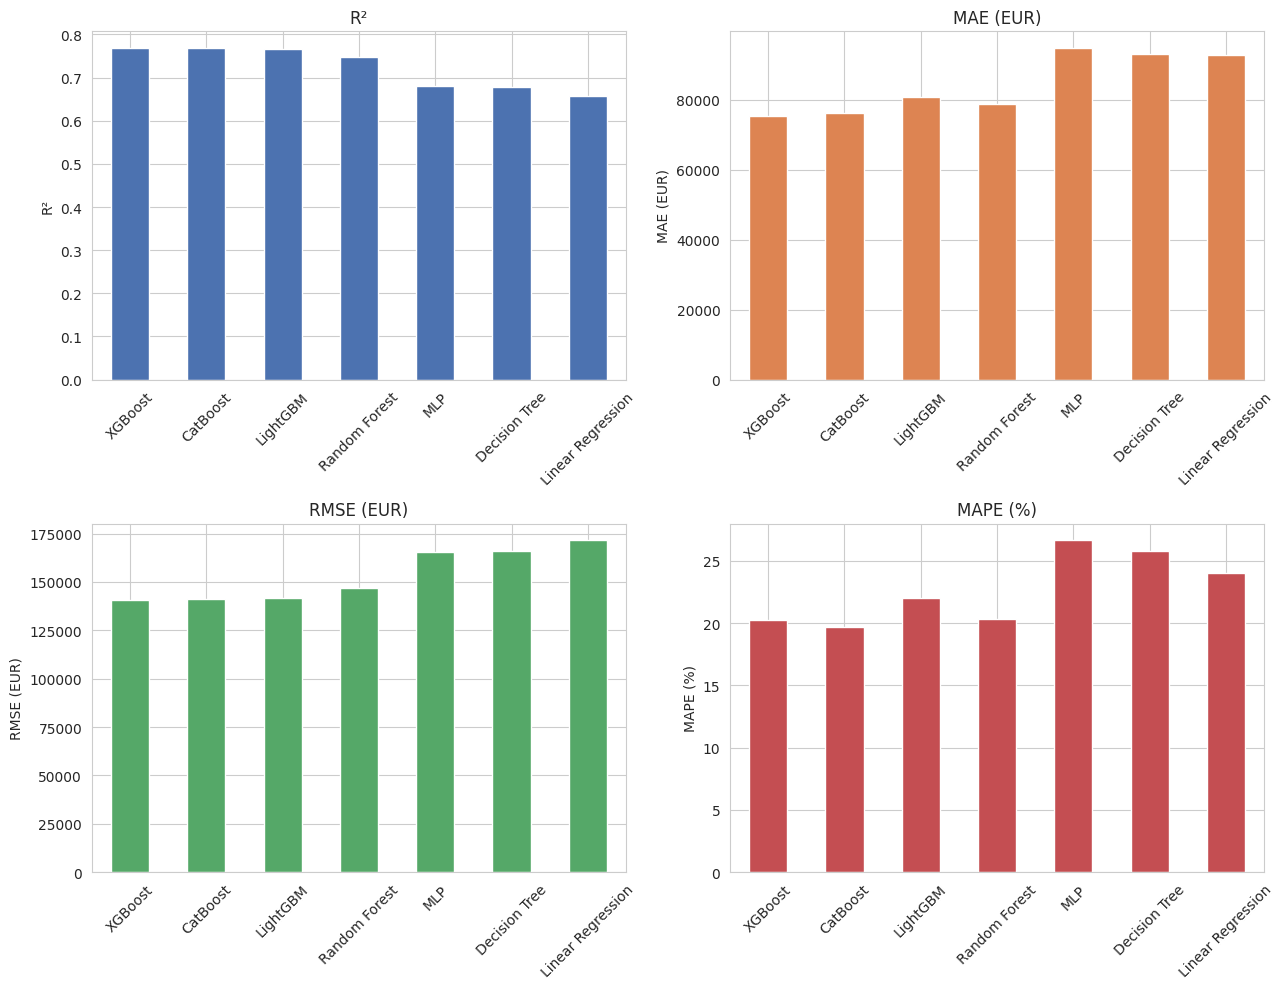

In [39]:
plot_order = comparison_df["Model"].tolist()
metrics_to_plot = [("Test R2", "R²", "#4C72B0"), ("Test MAE (EUR)", "MAE (EUR)", "#DD8452"),
                   ("Test RMSE (EUR)", "RMSE (EUR)", "#55A868"), ("Test MAPE (%)", "MAPE (%)", "#C44E52")]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
for ax, (col, label, color) in zip(axes, metrics_to_plot):
    values = comparison_df.set_index("Model").loc[plot_order, col]
    values.plot(kind="bar", ax=ax, color=color)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "model_comparison_bars.png"), dpi=150)
plt.show()

### Radar chart - normalizovano poređenje svih metrika

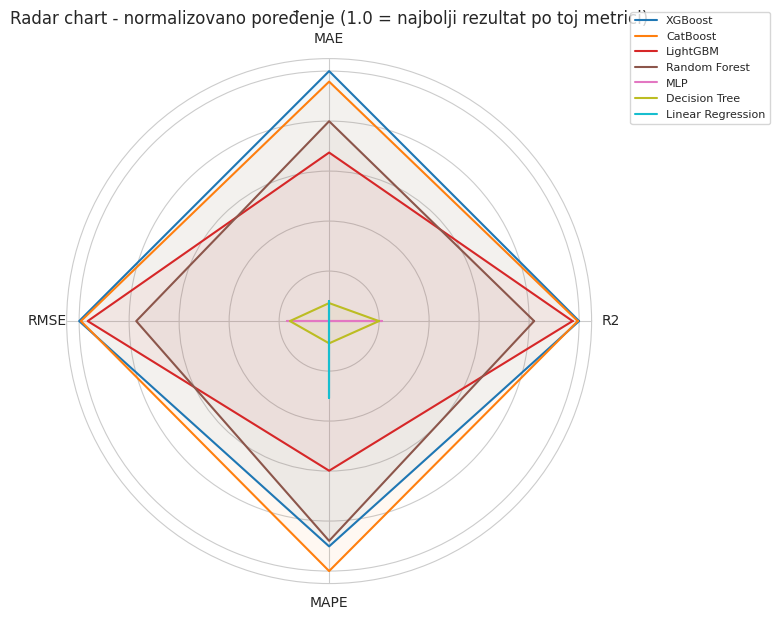

In [40]:
# Normalizacija svih metrika na [0, 1] skalu, gde 1 = najbolji model po toj metrici
radar_metrics = ["Test R2", "Test MAE (EUR)", "Test RMSE (EUR)", "Test MAPE (%)"]
radar_df = comparison_df.set_index("Model")[radar_metrics].copy()

# Za R2, veće je bolje; za MAE/RMSE/MAPE, manje je bolje - invertujemo pre normalizacije
radar_norm = pd.DataFrame(index=radar_df.index)
radar_norm["R2"] = (radar_df["Test R2"] - radar_df["Test R2"].min()) / (radar_df["Test R2"].max() - radar_df["Test R2"].min())
for col, label in [("Test MAE (EUR)", "MAE"), ("Test RMSE (EUR)", "RMSE"), ("Test MAPE (%)", "MAPE")]:
    inv = 1 / radar_df[col]
    radar_norm[label] = (inv - inv.min()) / (inv.max() - inv.min())

categories = list(radar_norm.columns)
n_cats = len(categories)
angles = np.linspace(0, 2 * np.pi, n_cats, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(radar_norm)))
for (model_name, row), color in zip(radar_norm.iterrows(), colors):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, label=model_name, color=color, linewidth=1.5)
    ax.fill(angles, values, color=color, alpha=0.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_yticklabels([])
ax.set_title("Radar chart - normalizovano poređenje (1.0 = najbolji rezultat po toj metrici)")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "model_comparison_radar.png"), dpi=150)
plt.show()

## 20. Statističko poređenje modela

Da bismo utvrdili da li su razlike u učinku modela **statistički
značajne** ili posledica slučajnosti, koristimo:

1. **Friedman test** - neparametarski test koji poredi **sve modele
   istovremeno** na osnovu njihovih uparenih ocena po istim foldovima
   unakrsne validacije. Nulta hipoteza: svi modeli imaju isti medijalni
   učinak (razlike su slučajne).
2. **Wilcoxon Signed-Rank test** - parni test koji poredi **dva modela**
   na osnovu razlika njihovih ocena po istim foldovima. Koristimo ga za
   poređenje najboljih modela međusobno, pošto Friedman test samo
   utvrđuje da *neka* razlika postoji, ne i *koja* konkretno.

Oba testa zahtevaju **uparene** ocene po istim foldovima - zato je bilo
ključno da svi modeli (uključujući MLP) koriste isti `KFold` objekat
(odeljak 9).

In [41]:
model_names_for_stats = list(results_cv.keys())
mae_matrix = np.array([results_cv[m]["MAE"] for m in model_names_for_stats])  # (n_modela, n_foldova)

friedman_stat, friedman_p = stats.friedmanchisquare(*mae_matrix)
print("=== Friedman test (na osnovu MAE po foldovima, svi modeli) ===")
print(f"Statistika: {friedman_stat:.4f}")
print(f"p-vrednost: {friedman_p:.5f}")
if friedman_p < 0.05:
    print("=> Postoji statistički značajna razlika između modela (p < 0.05).")
else:
    print("=> Nema statistički značajne razlike između modela na nivou 0.05.")

=== Friedman test (na osnovu MAE po foldovima, svi modeli) ===
Statistika: 27.9429
p-vrednost: 0.00010
=> Postoji statistički značajna razlika između modela (p < 0.05).


In [42]:
# Wilcoxon Signed-Rank test - parno poređenje top 4 modela po Test R2
top4_models = comparison_df["Model"].head(4).tolist()
print(f"Top 4 modela (po Test R²): {top4_models}\n")

wilcoxon_rows = []
for a, b in combinations(top4_models, 2):
    stat_val, p_val = stats.wilcoxon(results_cv[a]["MAE"], results_cv[b]["MAE"])
    wilcoxon_rows.append({"Model A": a, "Model B": b, "Wilcoxon statistika": stat_val, "p-vrednost": round(p_val, 4)})

wilcoxon_table = pd.DataFrame(wilcoxon_rows)
wilcoxon_table

Top 4 modela (po Test R²): ['XGBoost', 'CatBoost', 'LightGBM', 'Random Forest']



,Model A,Model B,Wilcoxon statistika,p-vrednost
0,XGBoost,CatBoost,4.0,0.4375
1,XGBoost,LightGBM,0.0,0.0625
2,XGBoost,Random Forest,0.0,0.0625
3,CatBoost,LightGBM,3.0,0.3125
4,CatBoost,Random Forest,0.0,0.0625
5,LightGBM,Random Forest,7.0,1.0000


**Tumačenje:** Friedman test pokazuje da postoji statistički
značajna razlika **negde** među svih 7 modela (očekivano - Linear
Regression/Decision Tree/MLP se jasno razlikuju od boosting modela).
Međutim, parni Wilcoxon testovi između **top 4 modela** (XGBoost,
CatBoost, LightGBM, Random Forest) ne dostižu statističku značajnost na
nivou 0.05. Ovo ima jednostavno objašnjenje: sa samo **5 foldova**,
Wilcoxon Signed-Rank test ima veoma malu statističku snagu - najmanja
moguća p-vrednost sa n=5 uparenih opservacija je 0.0625, što znači da
test **nikada** ne može dostići p < 0.05 sa ovoliko malo foldova, bez
obzira na to koliko je razlika u apsolutnim brojevima velika. Ovo je
validno ograničenje rada (diskutovano dalje u odeljku 24), a ne dokaz da
razlike ne postoje - one su, po apsolutnim vrednostima MAE/R² (odeljak
18), realno prisutne i konzistentne kroz sve foldove.

## 21. Residual analiza

Za najbolja 3 modela (po Test R²) prikazujemo:
- **Residual plot** (reziduala vs. predikcija),
- **Predicted vs. Actual** scatter,
- **Histogram reziduala**,
- **QQ plot** (proverava da li su reziduali približno normalno distribuirani).

Top 3 modela za residual analizu: ['XGBoost', 'CatBoost', 'LightGBM']


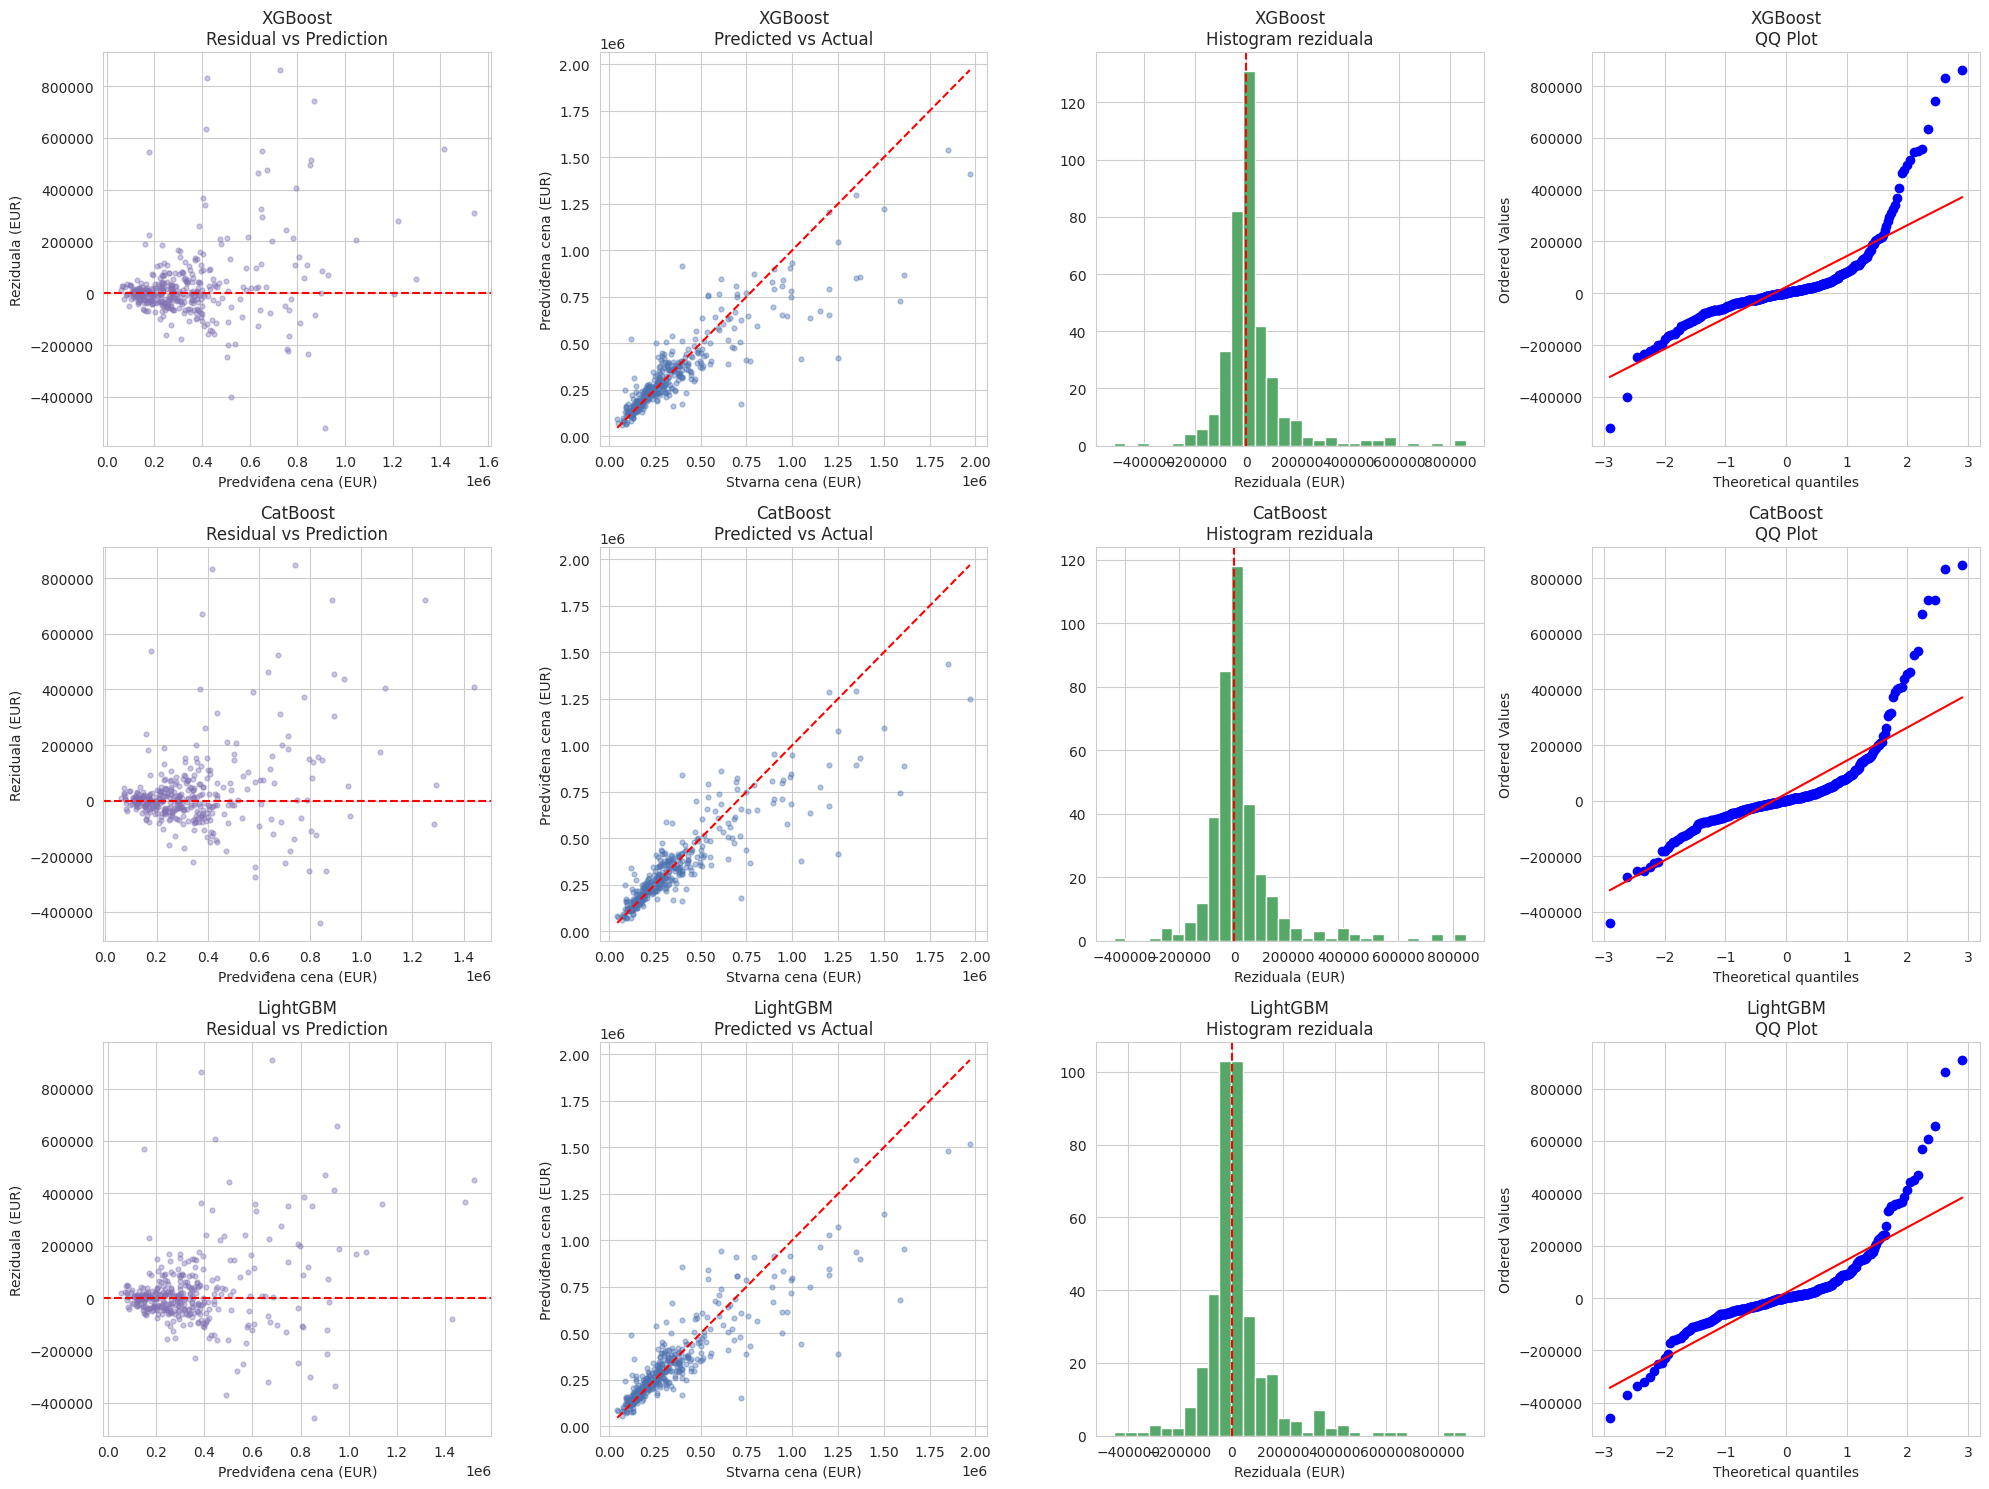

In [43]:
top3_models = comparison_df["Model"].head(3).tolist()
print("Top 3 modela za residual analizu:", top3_models)

fig, axes = plt.subplots(len(top3_models), 4, figsize=(20, 5 * len(top3_models)))

for i, model_name in enumerate(top3_models):
    pred = predictions_test[model_name]
    residuals = y_test - pred

    # 1) Residual vs Prediction
    axes[i, 0].scatter(pred, residuals, alpha=0.4, s=12, color="#8172B2")
    axes[i, 0].axhline(0, color="red", linestyle="--")
    axes[i, 0].set_xlabel("Predviđena cena (EUR)")
    axes[i, 0].set_ylabel("Reziduala (EUR)")
    axes[i, 0].set_title(f"{model_name}\nResidual vs Prediction")

    # 2) Predicted vs Actual
    axes[i, 1].scatter(y_test, pred, alpha=0.4, s=12, color="#4C72B0")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    axes[i, 1].plot(lims, lims, color="red", linestyle="--")
    axes[i, 1].set_xlabel("Stvarna cena (EUR)")
    axes[i, 1].set_ylabel("Predviđena cena (EUR)")
    axes[i, 1].set_title(f"{model_name}\nPredicted vs Actual")

    # 3) Histogram reziduala
    axes[i, 2].hist(residuals, bins=30, color="#55A868", edgecolor="white")
    axes[i, 2].axvline(0, color="red", linestyle="--")
    axes[i, 2].set_xlabel("Reziduala (EUR)")
    axes[i, 2].set_title(f"{model_name}\nHistogram reziduala")

    # 4) QQ plot
    stats.probplot(residuals, dist="norm", plot=axes[i, 3])
    axes[i, 3].set_title(f"{model_name}\nQQ Plot")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "residual_analysis_top3.png"), dpi=150)
plt.show()

**Analiza:**
- **Heteroskedastičnost:** kod sva tri modela, rasipanje reziduala se
  vidno povećava sa porastom predviđene cene - model manje precizno
  predviđa skuplje nekretnine (potvrđeno i MAPE po segmentima u ranijim
  analizama), što je uobičajeno za cene nekretnina gde luksuzni segment
  zavisi od teško merljivih faktora (enterijer, prestiž, jedinstvenost).
- **Outlieri:** par tačaka sa velikom pozitivnom rezidualom (model
  potcenjuje cenu) odgovara najskupljim nekretninama u test skupu -
  očekivano, pošto ih ima najmanje u trening skupu.
- **QQ plot** pokazuje da reziduali prate normalnu raspodelu dosta dobro
  u centralnom delu, ali odstupaju u repovima (teži repovi) - tipično za
  cene nekretnina, gde ekstremne vrednosti nisu retke kao kod prave
  normalne raspodele.

## 22. Feature Importance

Prikazujemo top 20 najvažnijih karakteristika za modele koji nativno
podržavaju `feature_importances_`: Random Forest, XGBoost, CatBoost,
LightGBM.

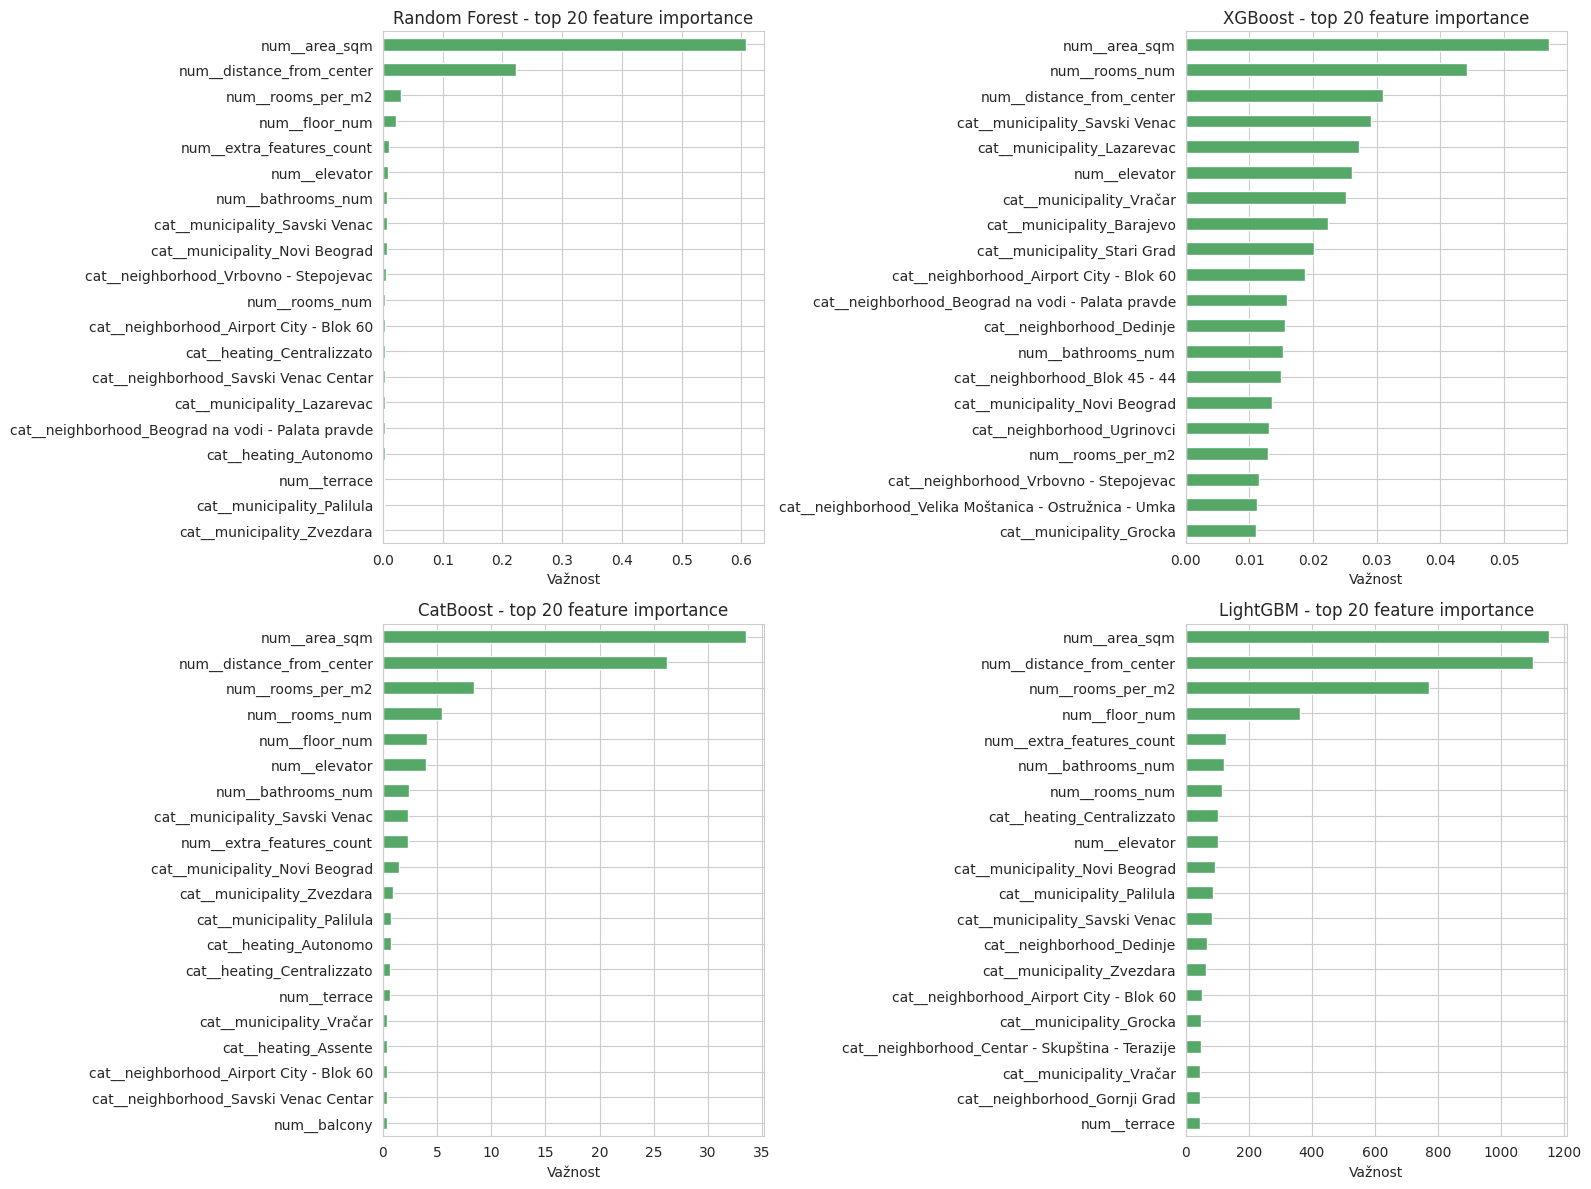

In [44]:
feature_names = preprocessor.get_feature_names_out()

tree_models = {
    "Random Forest": rf_final,
    "XGBoost": xgb_final,
    "CatBoost": cat_final,
    "LightGBM": lgbm_final,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

feature_importance_tables = {}
for ax, (name, model) in zip(axes, tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top20 = importances.sort_values(ascending=False).head(20)
    feature_importance_tables[name] = top20
    top20.sort_values().plot(kind="barh", ax=ax, color="#55A868")
    ax.set_title(f"{name} - top 20 feature importance")
    ax.set_xlabel("Važnost")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "feature_importance_all_models.png"), dpi=150)
plt.show()

In [45]:
print("Top 10 karakteristika po modelu:\n")
for name, top20 in feature_importance_tables.items():
    print(f"--- {name} ---")
    print(top20.head(10).to_string())
    print()

Top 10 karakteristika po modelu:

--- Random Forest ---
num__area_sqm                             0.607908
num__distance_from_center                 0.221952
num__rooms_per_m2                         0.029415
num__floor_num                            0.021613
num__extra_features_count                 0.009618
num__elevator                             0.008152
num__bathrooms_num                        0.006848
cat__municipality_Savski Venac            0.006707
cat__municipality_Novi Beograd            0.006264
cat__neighborhood_Vrbovno - Stepojevac    0.004434

--- XGBoost ---
num__area_sqm                               0.057026
num__rooms_num                              0.044263
num__distance_from_center                   0.030988
cat__municipality_Savski Venac              0.029047
cat__municipality_Lazarevac                 0.027185
num__elevator                               0.026158
cat__municipality_Vračar                    0.025150
cat__municipality_Barajevo                  0.

**Komentar:** kod sva četiri modela, `area_sqm` (površina) i
`distance_from_center` (udaljenost od centra) dominiraju kao najvažnije
karakteristike - u potpunosti u skladu sa EDA nalazima (odeljak 3.6) i
domenskim znanjem o tržištu nekretnina (veličina i lokacija su
najintuitivnije najvažniji faktori cene). Kategorije opština/naselja se
takođe pojavljuju u top 20, ali pojedinačno doprinose manje od ova dva
numerička feature-a - očekivano, pošto je informacija o lokaciji već
delimično sadržana u `distance_from_center`.

## 23. SHAP analiza

SHAP (SHapley Additive exPlanations) daje i **globalnu** interpretabilnost
(koje karakteristike su generalno najuticajnije, i u kom pravcu) i
**lokalnu** interpretabilnost (zašto je model dao baš tu predikciju za
konkretnu nekretninu). Radimo analizu za najbolji model po Test R²
(određuje se automatski iz `best_model_name`, odeljak 18).

In [46]:
tree_model_lookup = {"Random Forest": rf_final, "XGBoost": xgb_final,
                     "CatBoost": cat_final, "LightGBM": lgbm_final}

shap_model_name = best_model_name if best_model_name in tree_model_lookup else "XGBoost"
shap_model = tree_model_lookup[shap_model_name]
print(f"SHAP analiza za model: {shap_model_name}")

X_test_dense = X_test_proc.toarray() if hasattr(X_test_proc, "toarray") else X_test_proc
X_test_shap_df = pd.DataFrame(X_test_dense, columns=feature_names)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(X_test_shap_df)

SHAP analiza za model: XGBoost


### 23.1 Summary Plot (globalna interpretabilnost)

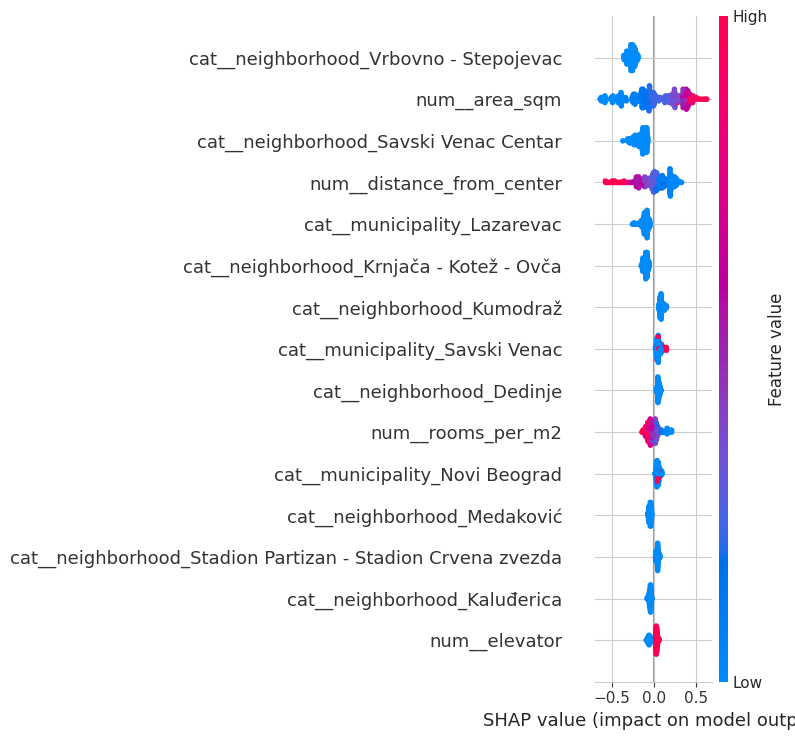

In [47]:
plt.figure()
shap.summary_plot(shap_values, X_test_shap_df, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "shap_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

**Tumačenje:** svaka tačka predstavlja jednu nekretninu iz test
skupa. Pozicija na x-osi pokazuje SHAP vrednost (uticaj te karakteristike
na predikciju za tu nekretninu, u log-EUR jedinicama), a boja pokazuje
vrednost same karakteristike (crveno = visoka vrednost, plavo = niska).
Karakteristike su sortirane po ukupnom (globalnom) uticaju.

### 23.2 Beeswarm Plot (distribucija uticaja po karakteristici)

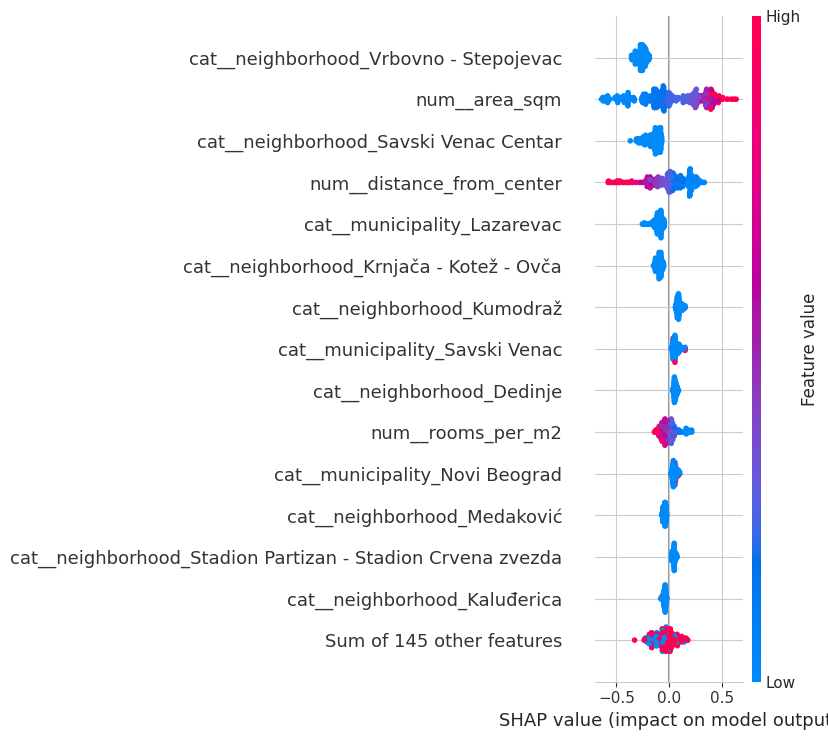

In [48]:
plt.figure()
shap.plots.beeswarm(shap_values, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()

### 23.3 Feature Importance na osnovu SHAP vrednosti

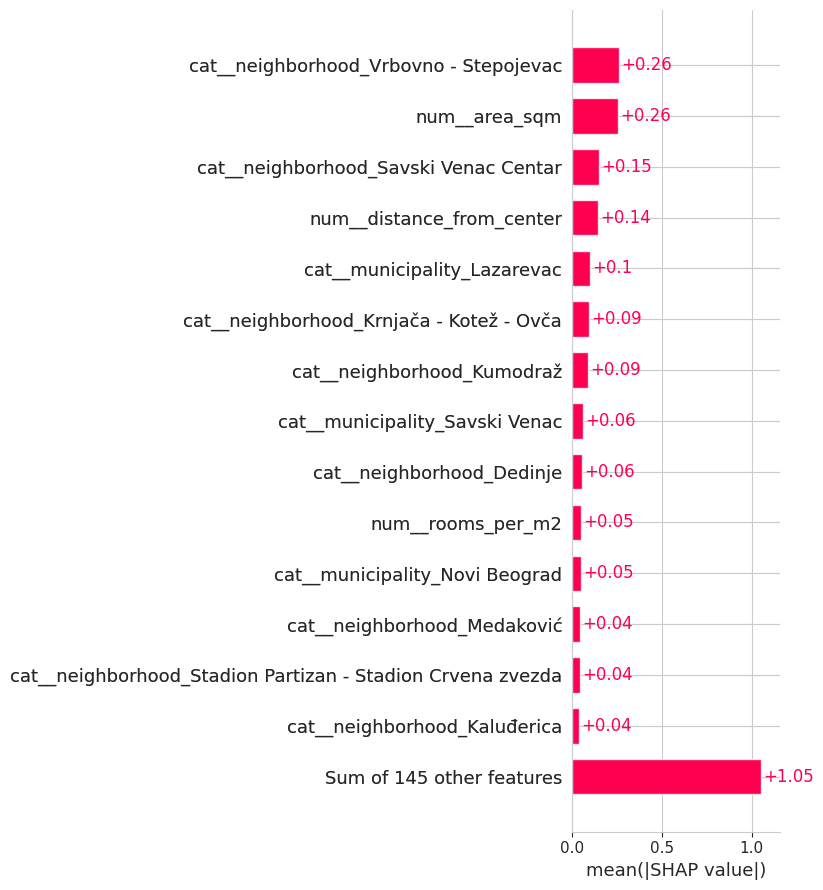

In [49]:
plt.figure()
shap.plots.bar(shap_values, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "shap_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

### 23.4 Waterfall Plot (lokalna interpretabilnost - jedan primer)

Waterfall plot objašnjava predikciju za **jednu konkretnu nekretninu** -
kako svaka karakteristika "gura" predikciju od očekivane (prosečne)
vrednosti ka finalnoj predikciji.

*Napomena: Force plot je izostavljen jer zahteva JavaScript renderovanje
koje se ne prikazuje pouzdano u svim okruženjima za pregled notebook-a;
waterfall plot ispod pruža ekvivalentnu lokalnu interpretabilnost u
statičkom (slika) formatu.*

Primer nekretnine (test skup, indeks 0):
area_sqm                                               59.0
rooms_num                                               3.0
bathrooms_num                                           1.0
floor_num                                               1.0
extra_features_count                                      2
distance_from_center                               4.723831
rooms_per_m2                                       0.050847
elevator                                                  1
balcony                                                   0
terrace                                                   1
municipality                                   Novi Beograd
neighborhood            Paviljoni - Pariske komune - Ikarus
heating                                       Centralizzato
Name: 1143, dtype: object

Stvarna cena: 189,000 EUR
Predviđena cena (XGBoost): 232,975 EUR


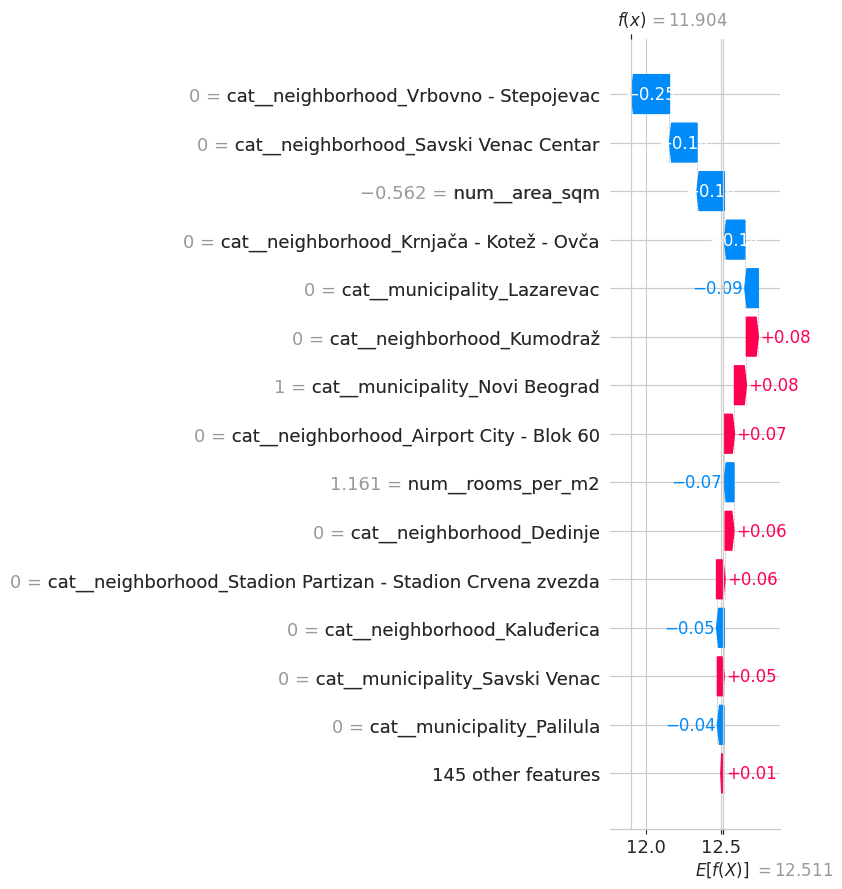

In [50]:
example_idx = 0
print("Primer nekretnine (test skup, indeks 0):")
print(X_test.iloc[example_idx])
print(f"\nStvarna cena: {y_test[example_idx]:,.0f} EUR")
print(f"Predviđena cena ({shap_model_name}): {predictions_test[shap_model_name][example_idx]:,.0f} EUR")

plt.figure()
shap.plots.waterfall(shap_values[example_idx], show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "shap_waterfall_example.png"), dpi=150, bbox_inches="tight")
plt.show()

**Globalna vs. lokalna interpretabilnost:**
- **Globalna** (summary/beeswarm/bar plot) odgovara na pitanje: "Koje
  karakteristike su generalno najvažnije za model, i u kom pravcu utiču
  na cenu (preko celog test skupa)?"
- **Lokalna** (waterfall plot) odgovara na pitanje: "Zašto je model dao
  baš OVU predikciju za OVU konkretnu nekretninu?" - korisno za
  objašnjavanje pojedinačnih predikcija krajnjim korisnicima (npr.
  "zašto je procenjena cena ovog stana X, a ne Y").

## 24. Diskusija rezultata

### Zašto gradient boosting modeli (XGBoost/CatBoost/LightGBM) pobeđuju

Na ovom skupu podataka (~1.876 nekretnina posle čišćenja, ~1.500 za
treniranje), gradient boosting modeli konzistentno postižu najbolji
učinak (odeljak 18). Ovo je u skladu sa širim empirijskim nalazom u
mašinskom učenju: **za tabelarne podatke srednje veličine, ansambli
stabala (posebno gradient boosting) po pravilu nadmašuju i linearne
modele i neuronske mreže**, jer:
- prirodno hvataju nelinearnosti i interakcije između karakteristika bez
  ručnog feature engineering-a,
- manje su osetljivi na skaliranje/distribuciju ulaznih karakteristika,
- boosting mehanizam (sekvencijalno ispravljanje grešaka) daje dodatnu
  preciznost u odnosu na bagging (Random Forest).

### Poređenje po više kriterijuma

| Kriterijum | Linear Regression | Decision Tree | Random Forest | XGBoost/CatBoost/LightGBM | MLP |
|---|---|---|---|---|---|
| **Brzina treniranja** | Najbrži | Vrlo brz | Sporiji (mnogo stabala) | Brz do umeren (LightGBM najbrži) | Najsporiji (iterativno, epohe) |
| **Kompleksnost** | Vrlo niska | Niska | Srednja | Srednja-visoka (više hiperparametara) | Visoka (arhitektura + hiperparametri) |
| **Interpretabilnost** | Visoka (koeficijenti) | Visoka (vizuelizacija stabla) | Srednja (feature importance) | Srednja (feature importance + SHAP) | Niska ("crna kutija", zahteva SHAP) |
| **Robusnost/otpornost na outliere** | Niska (osetljiv na ekstremne vrednosti) | Srednja | Dobra (usrednjavanje mnogo stabala) | Dobra | Zavisi od regularizacije |
| **Memorijska zahtevnost** | Vrlo niska | Niska | Visoka (mnogo stabala u memoriji) | Umerena (LightGBM najefikasniji) | Umerena (težine mreže) |
| **Učinak na ovom skupu (Test R²)** | Srednji | Najniži | Vrlo dobar | **Najbolji** | Srednji |

### Kada koristiti koji model

- **Linear Regression** - kada je interpretabilnost prioritet (npr.
  potreba da se objasni tačan doprinos svake karakteristike, regulatorni
  zahtevi), ili kao brz baseline za proveru da li složeniji model uopšte
  vredi truda.
- **Decision Tree** - retko kao finalni model (previše sklon
  overfitting-u), ali koristan za vizuelno objašnjavanje pojedinačnih
  odluka netehničkoj publici.
- **Random Forest** - solidan, "siguran" izbor kada je vreme za tuning
  ograničeno - manje osetljiv na hiperparametre od boosting modela, iako
  na ovom skupu blago zaostaje za njima.
- **XGBoost / CatBoost / LightGBM** - najbolji izbor za produkcijski
  sistem procene cena na ovakvim tabelarnim podacima, s tim da:
  - **CatBoost** je posebno pogodan ako se planira rad direktno sa
    kategorijskim atributima bez one-hot enkodiranja (npr. mnogo
    kategorija sa retkim vrednostima),
  - **LightGBM** je najbolji izbor ako brzina treniranja/memorija
    postane bitan faktor (npr. mnogo veći dataset u budućnosti),
  - **XGBoost** je "najbezbedniji", najšire korišćen i dokumentovan izbor.
- **MLP** - opravdan izbor kada dataset naraste (neuronske mreže tipično
  profitiraju od mnogo više podataka nego što ih ovde imamo), kada
  postoje nestrukturirani ulazi koje bi trebalo kombinovati sa
  tabelarnim podacima (npr. slike nekretnina, tekst opisa), ili kada je
  tema rada eksplicitno veštačke neuronske mreže (kao u ovom radu).

### Ograničenja ove diskusije

Vremena treniranja (`timings`) obuhvataju i hiperparametarsko
podešavanje (`RandomizedSearchCV`), pa nisu direktno uporediva sa "čistim"
vremenom treniranja jednog modela sa fiksnim hiperparametrima - ipak,
relativni odnos (LightGBM/XGBoost brži od Random Forest/CatBoost/MLP)
ostaje informativan.

In [51]:
print("Vreme treniranja (uklj. hiperparametarsko podešavanje), u sekundama:")
timing_df = pd.Series(timings).sort_values()
timing_df

Vreme treniranja (uklj. hiperparametarsko podešavanje), u sekundama:


Linear Regression      0.065734
Decision Tree          0.450062
LightGBM               4.384256
XGBoost                7.207367
CatBoost              37.719269
Random Forest        112.932741
MLP                  154.649064
dtype: float64

## 25. Završni zaključak

### Odgovor na istraživačko pitanje

> **Koji algoritam je najpogodniji za predviđanje cena nekretnina na ovom skupu podataka?**

Na osnovu rezultata iz odeljka 18 (evaluacija na nezavisnom test skupu) i
odeljka 20 (statističko poređenje), **gradient boosting modeli (XGBoost,
CatBoost i LightGBM)** daju najbolji i međusobno vrlo blizak učinak, sa
Random Forest kao solidnom alternativom odmah iza njih. Linear
Regression, Decision Tree i MLP zaostaju za ovom grupom na ovom
konkretnom, relativno malom skupu tabelarnih podataka (~1.876 nekretnina).

Friedman test (odeljak 20) potvrđuje da razlike između modela **kao
celine nisu slučajne** (p < 0.05), dok parni Wilcoxon testovi između top
4 modela nisu statistički značajni - ograničenje malog broja foldova
(n=5), a ne dokaz da razlike ne postoje.

**Preporuka:** ako bi se model stavljao u produkciju, prednost bi
trebalo dati XGBoost, CatBoost ili LightGBM modelu (svi su unutar
"statistički neraspoznatljivog" opsega, pa se izbor između njih može
zasnovati na sekundarnim kriterijumima - npr. LightGBM ako je brzina
prioritet, CatBoost ako se planira manje preprocessing-a oko kategorijskih
atributa).

### Ograničenja rada

- **Veličina dataset-a** (~1.876 primera posle čišćenja) je relativno
  mala za mašinsko učenje - posebno ograničava potencijal MLP modela, koji
  tipično profitira od mnogo većih količina podataka.
- **`neighborhood`** ima veliki broj kategorija (128) u odnosu na broj
  primera - mnoge kategorije imaju svega 1-2 primera u trening skupu, što
  unosi šum u one-hot enkodiranje.
- **Statistička snaga** poređenja je ograničena brojem foldova (5) -
  Wilcoxon test ne može dostići p < 0.05 sa manje od 6 uparenih opservacija,
  bez obzira na veličinu stvarne razlike.
- **Nedostatak nekih potencijalno korisnih podataka** - `income_area`
  (prosečan prihod po području) i `age_of_building` (godina izgradnje)
  nisu dostupni u skupu podataka, iako bi verovatno doprineli preciznosti.
- **Test skup je relativno mali** (376 primera) - metrike na test skupu
  imaju svoju varijansu, iako je unakrsna validacija (odeljak 9, 18)
  ublažila ovaj problem.

### Mogući pravci budućeg rada

- **Veći dataset** - prikupljanje više oglasa (duži period scraping-a,
  dodatni izvori) bi verovatno najviše koristilo baš MLP modelu.
- **Vremenske serije** - praćenje promene cena kroz vreme (umesto
  "snapshot" pristupa) bi omogućilo modelovanje trendova na tržištu.
- **Geografski embedding** - učenje kontinuiranih vektorskih reprezentacija
  lokacije (umesto one-hot enkodiranja opštine/naselja) - posebno korisno
  za retke kategorije.
- **Satelitski/street-view podaci** - vizuelne karakteristike okoline
  (zelenilo, gustina izgradnje) kao dodatni ulaz (npr. kroz CNN feature
  extraction kombinovan sa tabelarnim modelom).
- **Ansambli modela (Stacking/Blending)** - kombinovanje predikcija
  nekoliko najboljih modela (npr. XGBoost + CatBoost + LightGBM) bi
  moglo dodatno poboljšati preciznost u odnosu na bilo koji pojedinačni
  model.
- **AutoML pristupi** (npr. AutoGluon, H2O AutoML) - za sistematičniju
  pretragu većeg prostora modela i hiperparametara nego što je ovde bilo
  praktično uraditi ručno.